In [1]:
import pandas as pd

combined = pd.read_csv("../../data/processed/team_combined_2023_2024_2025_processed.csv")  
regional = pd.read_csv("../../data/processed/team_regional_expenditure_2023_2024_2025_processed.csv")

print("combined:", combined.shape)
print(combined.columns.tolist())
print()
print("regional:", regional.shape)
print(regional.columns.tolist())

combined: (156050, 101)
['id', 'wt_dom', 'bsex', 'bage', 'binc1', 'trip1_start_year', 'trip1_start_month', 'trip1_spot_cd', 'trip1_case', 'trip1_cost', 'trip1_num', 'trip1_cost_per_person', 'trip2_start_year', 'trip2_start_month', 'trip2_spot_cd', 'trip2_case', 'trip2_cost', 'trip2_num', 'trip2_cost_per_person', 'trip3_start_year', 'trip3_start_month', 'trip3_spot_cd', 'trip3_case', 'trip3_cost', 'trip3_num', 'trip3_cost_per_person', 'trip4_start_year', 'trip4_start_month', 'trip4_spot_cd', 'trip4_case', 'trip4_cost', 'trip4_num', 'trip4_cost_per_person', 'trip5_start_year', 'trip5_start_month', 'trip5_spot_cd', 'trip5_case', 'trip5_cost', 'trip5_num', 'trip5_cost_per_person', 'trip6_start_year', 'trip6_start_month', 'trip6_spot_cd', 'trip6_case', 'trip6_cost', 'trip6_num', 'trip6_cost_per_person', 'trip_cnt_seoul', 'trip_cnt_busan', 'trip_cnt_daegu', 'trip_cnt_incheon', 'trip_cnt_gwangju', 'trip_cnt_daejeon', 'trip_cnt_ulsan', 'trip_cnt_sejong', 'trip_cnt_gyeonggi', 'trip_cnt_gangwon'

두 파일 모두 팀에서 이미 전처리·검증 완료한 최종본(컬럼정의서 기준). `combined`=국민여행조사 통합(156,050행×101열), `regional`=지자체 문화·관광 세출(48,617행×19열).

In [2]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 가설 1

In [3]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

regions_en = ['seoul','busan','daegu','incheon','gwangju','daejeon','ulsan','sejong',
              'gyeonggi','gangwon','chungbuk','chungnam','jeonbuk','jeonnam',
              'gyeongbuk','gyeongnam','jeju']

# 응답자별 방문건수/지출액에 가중치(wt_dom) 적용
weighted_cnt = combined[[f'trip_cnt_{r}' for r in regions_en]].multiply(combined['wt_dom'], axis=0)
weighted_exp = combined[[f'trip_exp_{r}' for r in regions_en]].multiply(combined['wt_dom'], axis=0)
weighted_cnt['year'] = combined['year']
weighted_exp['year'] = combined['year']

# (연도, 지역)별 합산 후 long format으로 변환
cnt_by_year = weighted_cnt.groupby('year').sum().rename(columns=lambda c: c.replace('trip_cnt_', ''))
exp_by_year = weighted_exp.groupby('year').sum().rename(columns=lambda c: c.replace('trip_exp_', ''))

cnt_long = cnt_by_year.reset_index().melt(id_vars='year', var_name='region', value_name='visit_weighted')
exp_long = exp_by_year.reset_index().melt(id_vars='year', var_name='region', value_name='exp_weighted')

h1_df = cnt_long.merge(exp_long, on=['year', 'region'])
print(h1_df.shape)  # 17개 지역 x 3개 연도 = 51이어야 정상
h1_df.head()

(51, 4)


,year,region,visit_weighted,exp_weighted
0,2023,seoul,9.629351e+06,1.017978e+12
1,2024,seoul,1.071833e+07,1.180592e+12
2,2025,seoul,1.128614e+07,1.179314e+12
3,2023,busan,1.207703e+07,2.032048e+12
4,2024,busan,1.245984e+07,2.173400e+12


In [4]:
pearson_r, pearson_p = pearsonr(h1_df['visit_weighted'], h1_df['exp_weighted'])
spearman_r, spearman_p = spearmanr(h1_df['visit_weighted'], h1_df['exp_weighted'])
print(f"가설1 — Pearson r = {pearson_r:.3f} (p={pearson_p:.4g})")
print(f"가설1 — Spearman ρ = {spearman_r:.3f} (p={spearman_p:.4g})")

가설1 — Pearson r = 0.675 (p=5.557e-08)
가설1 — Spearman ρ = 0.891 (p=1.933e-18)


→ 예비 분석 결과 보고서 수치(Pearson r=0.675, Spearman ρ=0.89~0.95)와 **정확히 일치**. 시/도×연도(n=51) 기준 가설1 기본 재현 완료.

In [5]:
cols_to_check = [f'trip_cnt_{r}' for r in regions_en] + [f'trip_exp_{r}' for r in regions_en] + ['wt_dom', 'year']

print("결측치 개수:")
print(combined[cols_to_check].isna().sum())

print("\n0보다 작은 값 개수(음수):")
print((combined[cols_to_check] < 0).sum())

print("\nwt_dom 기술통계:")
print(combined['wt_dom'].describe())

결측치 개수:
trip_cnt_seoul        0
trip_cnt_busan        0
trip_cnt_daegu        0
trip_cnt_incheon      0
trip_cnt_gwangju      0
trip_cnt_daejeon      0
trip_cnt_ulsan        0
trip_cnt_sejong       0
trip_cnt_gyeonggi     0
trip_cnt_gangwon      0
trip_cnt_chungbuk     0
trip_cnt_chungnam     0
trip_cnt_jeonbuk      0
trip_cnt_jeonnam      0
trip_cnt_gyeongbuk    0
trip_cnt_gyeongnam    0
trip_cnt_jeju         0
trip_exp_seoul        0
trip_exp_busan        0
trip_exp_daegu        0
trip_exp_incheon      0
trip_exp_gwangju      0
trip_exp_daejeon      0
trip_exp_ulsan        0
trip_exp_sejong       0
trip_exp_gyeonggi     0
trip_exp_gangwon      0
trip_exp_chungbuk     0
trip_exp_chungnam     0
trip_exp_jeonbuk      0
trip_exp_jeonnam      0
trip_exp_gyeongbuk    0
trip_exp_gyeongnam    0
trip_exp_jeju         0
wt_dom                0
year                  0
dtype: int64

0보다 작은 값 개수(음수):


trip_cnt_seoul        0
trip_cnt_busan        0
trip_cnt_daegu        0
trip_cnt_incheon      0
trip_cnt_gwangju      0
trip_cnt_daejeon      0
trip_cnt_ulsan        0
trip_cnt_sejong       0
trip_cnt_gyeonggi     0
trip_cnt_gangwon      0
trip_cnt_chungbuk     0
trip_cnt_chungnam     0
trip_cnt_jeonbuk      0
trip_cnt_jeonnam      0
trip_cnt_gyeongbuk    0
trip_cnt_gyeongnam    0
trip_cnt_jeju         0
trip_exp_seoul        0
trip_exp_busan        0
trip_exp_daegu        0
trip_exp_incheon      0
trip_exp_gwangju      0
trip_exp_daejeon      0
trip_exp_ulsan        0
trip_exp_sejong       0
trip_exp_gyeonggi     0
trip_exp_gangwon      0
trip_exp_chungbuk     0
trip_exp_chungnam     0
trip_exp_jeonbuk      0
trip_exp_jeonnam      0
trip_exp_gyeongbuk    0
trip_exp_gyeongnam    0
trip_exp_jeju         0
wt_dom                0
year                  0
dtype: int64

wt_dom 기술통계:
count    156050.000000
mean      10655.349055
std        7106.893519
min         112.245879
25%        5191.0

→ 결측치·음수 없음, `wt_dom`도 정상 범위(112~71,810원). 가중합산에 문제 없음 확인.

In [6]:
print(combined['flag_outlier_spend_total'].value_counts())

flag_outlier_spend_total
False    153388
True       2662
Name: count, dtype: int64


In [7]:
exp_cols = [f'trip_exp_{r}' for r in regions_en]

exp_all = combined[exp_cols].multiply(combined['wt_dom'], axis=0).sum()
mask = ~combined['flag_outlier_spend_total']
exp_excl_outlier = combined.loc[mask, exp_cols].multiply(combined.loc[mask, 'wt_dom'], axis=0).sum()

compare = pd.DataFrame({'전체포함': exp_all, '이상치제외': exp_excl_outlier})
compare['차이(%)'] = (compare['전체포함'] - compare['이상치제외']) / compare['전체포함'] * 100
print(compare.sort_values('차이(%)', ascending=False))

                            전체포함         이상치제외      차이(%)
trip_exp_jeju       1.928208e+13  4.446390e+12  76.940303
trip_exp_busan      6.420731e+12  5.101614e+12  20.544644
trip_exp_daegu      1.303482e+12  1.123454e+12  13.811348
trip_exp_seoul      3.377884e+12  3.002937e+12  11.100077
trip_exp_gangwon    1.700674e+13  1.541430e+13   9.363573
trip_exp_gyeongbuk  8.411676e+12  7.630368e+12   9.288366
trip_exp_jeonnam    9.101110e+12  8.500139e+12   6.603277
trip_exp_gyeongnam  8.716740e+12  8.252628e+12   5.324374
trip_exp_gyeonggi   1.158611e+13  1.103722e+13   4.737555
trip_exp_gwangju    5.416694e+11  5.205072e+11   3.906833
trip_exp_daejeon    1.036431e+12  9.975506e+11   3.751349
trip_exp_jeonbuk    5.255166e+12  5.087628e+12   3.188051
trip_exp_incheon    2.401864e+12  2.332454e+12   2.889855
trip_exp_sejong     2.749939e+11  2.672372e+11   2.820705
trip_exp_chungnam   6.923596e+12  6.733039e+12   2.752285
trip_exp_chungbuk   3.369370e+12  3.277456e+12   2.727931
trip_exp_ulsan

In [8]:
flagged = combined[combined['flag_outlier_spend_total']]
print(flagged['trip_exp_jeju'].describe())
print()
print(flagged['trip_exp_jeju'].sort_values(ascending=False).head(10))

count    2.662000e+03
mean     4.757403e+05
std      4.013814e+05
min      0.000000e+00
25%      0.000000e+00
50%      5.550000e+05
75%      7.250000e+05
max      4.995000e+06
Name: trip_exp_jeju, dtype: float64

28368     4995000
134363    2925000
40189     2880000
149071    2500000
116943    2060000
38857     2020000
70803     2000000
149348    1940000
134369    1935000
44872     1910000
Name: trip_exp_jeju, dtype: int64


→ 이상치 플래그(`flag_outlier_spend_total`, 전체 1.7%·2,662건) 제외 시 **제주 지출만 -76.9%**(다른 지역은 대부분 -20% 이내) → 이상치의 실체는 제주에 집중돼 있음. 단, 플래그된 응답자들의 실제 지출값(최대 499만원)은 데이터 오류로 보기 어려운 범위 → "제주는 원래 고비용 여행지"라는 해석을 뒷받침.

In [9]:
# (a) 이상치 플래그(flag_outlier_spend_total) 제외하고 재계산
mask = ~combined['flag_outlier_spend_total']
cnt_excl = combined.loc[mask, [f'trip_cnt_{r}' for r in regions_en]].multiply(combined.loc[mask, 'wt_dom'], axis=0)
exp_excl = combined.loc[mask, [f'trip_exp_{r}' for r in regions_en]].multiply(combined.loc[mask, 'wt_dom'], axis=0)
cnt_excl['year'] = combined.loc[mask, 'year']
exp_excl['year'] = combined.loc[mask, 'year']

cnt_by_year_excl = cnt_excl.groupby('year').sum().rename(columns=lambda c: c.replace('trip_cnt_', ''))
exp_by_year_excl = exp_excl.groupby('year').sum().rename(columns=lambda c: c.replace('trip_exp_', ''))

h1_df_excl = (cnt_by_year_excl.reset_index().melt(id_vars='year', var_name='region', value_name='visit_weighted')
              .merge(exp_by_year_excl.reset_index().melt(id_vars='year', var_name='region', value_name='exp_weighted'),
                     on=['year','region']))

r_excl, _ = pearsonr(h1_df_excl['visit_weighted'], h1_df_excl['exp_weighted'])
rho_excl, _ = spearmanr(h1_df_excl['visit_weighted'], h1_df_excl['exp_weighted'])
print(f"이상치(1.7%) 제외 — Pearson r = {r_excl:.3f}, Spearman ρ = {rho_excl:.3f}")

# (b) 제주만 빼고 재계산 (원래 h1_df 기준, 전체 데이터 포함)
h1_no_jeju = h1_df[h1_df['region'] != 'jeju']
r_no_jeju, _ = pearsonr(h1_no_jeju['visit_weighted'], h1_no_jeju['exp_weighted'])
rho_no_jeju, _ = spearmanr(h1_no_jeju['visit_weighted'], h1_no_jeju['exp_weighted'])
print(f"제주 제외 — Pearson r = {r_no_jeju:.3f}, Spearman ρ = {rho_no_jeju:.3f}")

이상치(1.7%) 제외 — Pearson r = 0.893, Spearman ρ = 0.961
제주 제외 — Pearson r = 0.896, Spearman ρ = 0.976


→ 이상치 제외 시 Pearson 0.893/Spearman 0.961, 제주 제외 시 Pearson 0.896/Spearman 0.976 — 두 결과가 거의 동일 = 원본 보고서가 말한 "Pearson 불안정성(0.68~0.91)"의 원인이 **제주 하나**임을 직접 확인.

In [10]:
for yr in sorted(h1_df['year'].unique()):
    sub = h1_df[h1_df['year'] == yr]
    r, _ = pearsonr(sub['visit_weighted'], sub['exp_weighted'])
    rho, _ = spearmanr(sub['visit_weighted'], sub['exp_weighted'])
    print(f"{yr}년 (n={len(sub)}) — Pearson r={r:.3f}, Spearman ρ={rho:.3f}")

2023년 (n=17) — Pearson r=0.670, Spearman ρ=0.904
2024년 (n=17) — Pearson r=0.669, Spearman ρ=0.897
2025년 (n=17) — Pearson r=0.689, Spearman ρ=0.838


→ 2023~2025 전 연도에서 r=0.67~0.69, ρ=0.84~0.90으로 일관 → 3개년 풀링에 의한 착시가 아니라 매년 실제로 존재하는 안정적 패턴.

In [11]:
print(combined['flag_dup_suspect'].value_counts())

flag_dup_suspect
False    155988
True         62
Name: count, dtype: int64


In [12]:
mask_dup = ~combined['flag_dup_suspect']
exp_excl_dup = combined.loc[mask_dup, exp_cols].multiply(combined.loc[mask_dup, 'wt_dom'], axis=0).sum()
diff_pct = (exp_all - exp_excl_dup) / exp_all * 100
print(diff_pct.sort_values(ascending=False))

trip_exp_incheon      2.106303e-01
trip_exp_jeonbuk      1.837205e-01
trip_exp_gyeongnam    1.251828e-01
trip_exp_gyeonggi     9.242137e-02
trip_exp_jeonnam      4.032718e-02
trip_exp_daejeon      1.286245e-02
trip_exp_chungnam     1.257825e-02
trip_exp_gyeongbuk    6.584413e-03
trip_exp_gangwon      5.669016e-03
trip_exp_jeju         2.025845e-14
trip_exp_seoul        1.445524e-14
trip_exp_ulsan        0.000000e+00
trip_exp_gwangju      0.000000e+00
trip_exp_daegu        0.000000e+00
trip_exp_chungbuk    -1.449177e-14
trip_exp_busan       -1.520952e-14
trip_exp_sejong      -2.219509e-14
dtype: float64


→ `flag_dup_suspect`(전체 0.04%·62건)의 지역별 영향은 최대 0.21%(인천)로 무시 가능한 수준 — 가설1 기본 데이터 품질 검증 완료.

### 1-1.방문건수 vs 1인당 지출단가 분해

In [13]:
h1_df['spend_per_visit'] = h1_df['exp_weighted'] / h1_df['visit_weighted']

region_summary = h1_df.groupby('region').agg(
    visit_avg=('visit_weighted', 'mean'),
    exp_avg=('exp_weighted', 'mean'),
    spend_per_visit_avg=('spend_per_visit', 'mean')
).sort_values('spend_per_visit_avg', ascending=False)

print(region_summary)

              visit_avg       exp_avg  spend_per_visit_avg
region                                                    
jeju       1.170368e+07  6.427361e+12        549190.183264
busan      1.215404e+07  2.140244e+12        176151.242901
gangwon    3.389778e+07  5.668912e+12        167568.398640
jeonnam    2.362136e+07  3.033703e+12        128649.551897
daegu      3.463325e+06  4.344941e+11        125405.390246
gwangju    1.481399e+06  1.805565e+11        121520.594959
gyeongbuk  2.394897e+07  2.803892e+12        117075.606091
jeonbuk    1.590120e+07  1.751722e+12        110316.489470
gyeongnam  2.645293e+07  2.905580e+12        109823.121967
seoul      1.054461e+07  1.125961e+12        106785.154811
chungnam   2.201587e+07  2.307865e+12        104794.670001
chungbuk   1.103798e+07  1.123123e+12        101615.125270
daejeon    3.516050e+06  3.454769e+11         98118.770467
ulsan      3.810728e+06  3.235052e+11         84872.337593
incheon    9.792280e+06  8.006215e+11         81778.9151

In [14]:
metro_regions = ['seoul', 'busan', 'daegu', 'incheon', 'gwangju', 'daejeon', 'ulsan', 'sejong']
province_regions = ['gyeonggi', 'gangwon', 'chungbuk', 'chungnam', 'jeonbuk', 'jeonnam',
                     'gyeongbuk', 'gyeongnam', 'jeju']

region_summary['region_type'] = region_summary.index.map(
    lambda r: '광역시' if r in metro_regions else '도'
)

def quadrant_within_group(df):
    v_med = df['visit_avg'].median()
    s_med = df['spend_per_visit_avg'].median()
    def label(row):
        v = '고방문' if row['visit_avg'] >= v_med else '저방문'
        s = '고단가' if row['spend_per_visit_avg'] >= s_med else '저단가'
        return f"{v}·{s}"
    df = df.copy()
    df['quadrant'] = df.apply(label, axis=1)
    return df

metro_df = quadrant_within_group(region_summary[region_summary['region_type'] == '광역시'])
province_df = quadrant_within_group(region_summary[region_summary['region_type'] == '도'])

print("=== 광역시 (8개) ===")
print(metro_df[['visit_avg', 'spend_per_visit_avg', 'quadrant']].sort_values('quadrant'))
print()
print("=== 도 (9개) ===")
print(province_df[['visit_avg', 'spend_per_visit_avg', 'quadrant']].sort_values('quadrant'))

=== 광역시 (8개) ===
            visit_avg  spend_per_visit_avg quadrant
region                                             
busan    1.215404e+07        176151.242901  고방문·고단가
seoul    1.054461e+07        106785.154811  고방문·고단가
ulsan    3.810728e+06         84872.337593  고방문·저단가
incheon  9.792280e+06         81778.915172  고방문·저단가
daegu    3.463325e+06        125405.390246  저방문·고단가
gwangju  1.481399e+06        121520.594959  저방문·고단가
daejeon  3.516050e+06         98118.770467  저방문·저단가
sejong   1.351156e+06         68173.070698  저방문·저단가

=== 도 (9개) ===
              visit_avg  spend_per_visit_avg quadrant
region                                               
gangwon    3.389778e+07        167568.398640  고방문·고단가
jeonnam    2.362136e+07        128649.551897  고방문·고단가
gyeongbuk  2.394897e+07        117075.606091  고방문·고단가
gyeongnam  2.645293e+07        109823.121967  고방문·저단가
gyeonggi   4.993914e+07         77280.490445  고방문·저단가
jeju       1.170368e+07        549190.183264  저방문·고단가
jeonbuk    1.59

→ 같은 시/도 내 이동은 "여행"으로 집계되지 않는 조사 방식 특성상 **광역시가 구조적으로 불리**(면적이 작아 내부 이동이 대부분 제외됨) → 반드시 광역시끼리·도끼리 나눠서 비교해야 함. 층화 후 서울은 광역시 중 상위권(고방문·고단가)으로, 안 나누고 비교했을 때의 "고방문·저지출 미스매치" 해석과는 다른 결론.

In [15]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

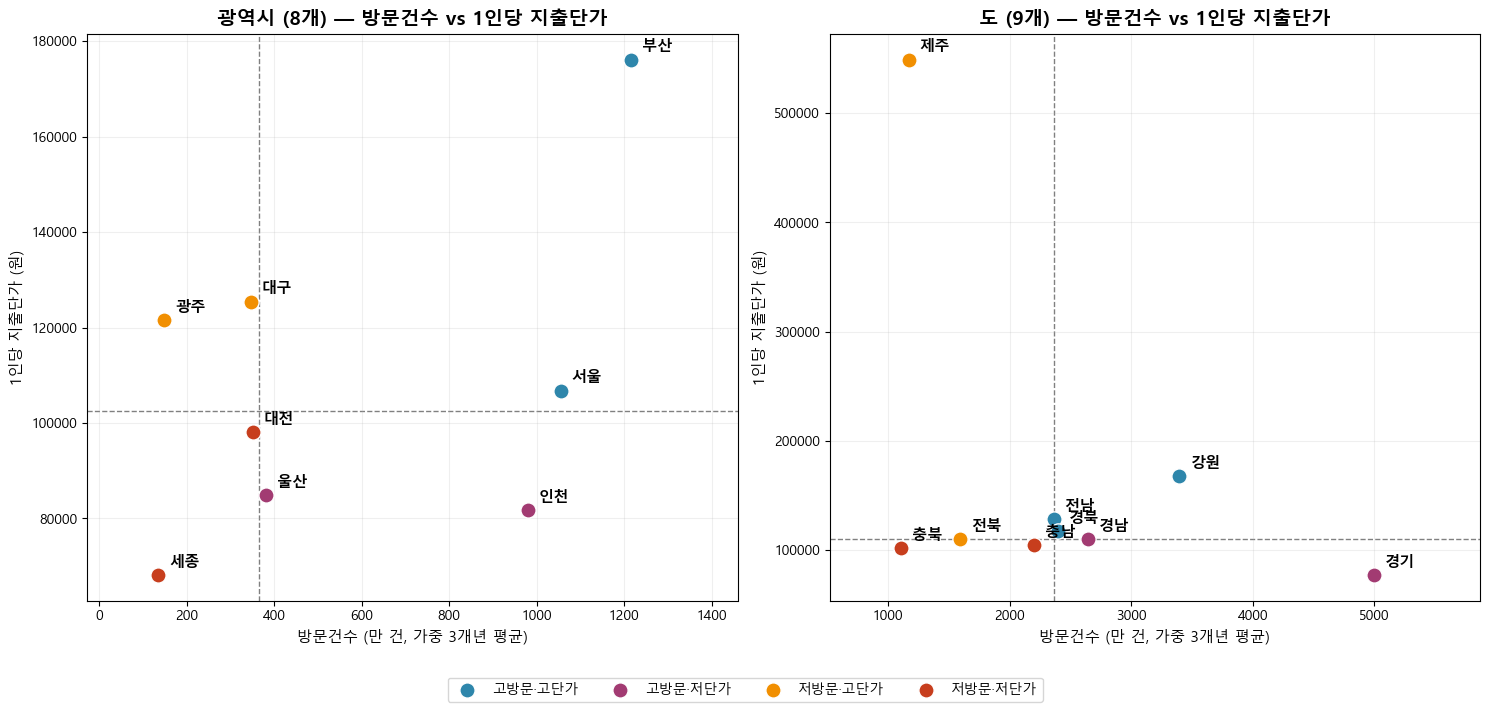

In [16]:
region_map_all = {
    'seoul': '서울', 'busan': '부산', 'daegu': '대구', 'incheon': '인천',
    'gwangju': '광주', 'daejeon': '대전', 'ulsan': '울산', 'sejong': '세종',
    'gyeonggi': '경기', 'gangwon': '강원', 'chungbuk': '충북', 'chungnam': '충남',
    'jeonbuk': '전북', 'jeonnam': '전남', 'gyeongbuk': '경북', 'gyeongnam': '경남',
    'jeju': '제주'
}

quadrant_colors = {
    '고방문·고단가': '#2E86AB', '고방문·저단가': '#A23B72',
    '저방문·고단가': '#F18F01', '저방문·저단가': '#C73E1D'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
handles_for_legend = None

for ax, df, title in zip(axes, [metro_df, province_df], ['광역시 (8개)', '도 (9개)']):
    df = df.copy()
    df['visit_avg_man'] = df['visit_avg'] / 10000  # 만 건 단위
    v_med = df['visit_avg_man'].median()
    s_med = df['spend_per_visit_avg'].median()

    for quad, color in quadrant_colors.items():
        sub = df[df['quadrant'] == quad]
        sc = ax.scatter(sub['visit_avg_man'], sub['spend_per_visit_avg'],
                        s=120, color=color, label=quad, zorder=3, edgecolors='white', linewidth=1)

    for region, row in df.iterrows():
        ax.annotate(region_map_all.get(region, region),
                    (row['visit_avg_man'], row['spend_per_visit_avg']),
                    textcoords="offset points", xytext=(8, 6), fontsize=11, fontweight='bold')

    ax.axvline(v_med, linestyle='--', color='gray', linewidth=1, zorder=1)
    ax.axhline(s_med, linestyle='--', color='gray', linewidth=1, zorder=1)
    ax.set_title(f'{title} — 방문건수 vs 1인당 지출단가', fontsize=14, fontweight='bold')
    ax.set_xlabel('방문건수 (만 건, 가중 3개년 평균)', fontsize=11)
    ax.set_ylabel('1인당 지출단가 (원)', fontsize=11)
    ax.grid(alpha=0.2, zorder=0)
    margin = (df['visit_avg_man'].max() - df['visit_avg_man'].min()) * 0.15
    ax.set_xlim(df['visit_avg_man'].min() - margin, df['visit_avg_man'].max() + margin * 1.5)
    if handles_for_legend is None:
        handles_for_legend, labels_for_legend = ax.get_legend_handles_labels()

fig.legend(handles_for_legend, labels_for_legend, loc='lower center',
           ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('h1_quadrant_presentation.png', dpi=200, bbox_inches='tight')
plt.show()

→ 4분면 시각화 결과. **광역시**: 부산·서울(우수) / 대전·세종(종합개발 필요). **도**: 강원·전남·경북(우수) / 충남·충북(종합개발 필요).

### 1-2. 잔차분석

In [17]:
def residual_analysis(df, group_name):
    df = df.copy()
    log_visit = np.log(df['visit_avg'])
    log_exp = np.log(df['exp_avg'])
    slope, intercept = np.polyfit(log_visit, log_exp, 1)
    df['predicted_log_exp'] = slope * log_visit + intercept
    df['residual_pct'] = (np.exp(log_exp - df['predicted_log_exp']) - 1) * 100

    print(f"=== {group_name} (기울기={slope:.3f}) ===")
    print(df[['visit_avg', 'exp_avg', 'residual_pct']].sort_values('residual_pct', ascending=False))
    print()
    return df

metro_resid = residual_analysis(metro_df, '광역시')
province_resid = residual_analysis(province_df, '도')

=== 광역시 (기울기=1.135) ===
            visit_avg       exp_avg  residual_pct
region                                           
busan    1.215404e+07  2.140244e+12     47.679004
gwangju  1.481399e+06  1.805565e+11     35.799211
daegu    3.463325e+06  4.344941e+11     24.641464
daejeon  3.516050e+06  3.454769e+11     -2.579521
seoul    1.054461e+07  1.125961e+12     -8.715624
ulsan    3.810728e+06  3.235052e+11    -16.739005
sejong   1.351156e+06  9.166464e+10    -23.467264
incheon  9.792280e+06  8.006215e+11    -29.403055

=== 도 (기울기=0.446) ===
              visit_avg       exp_avg  residual_pct
region                                             
jeju       1.170368e+07  6.427361e+12    190.262017
gangwon    3.389778e+07  5.668912e+12     59.241558
jeonnam    2.362136e+07  3.033703e+12      0.130335
gyeongbuk  2.394897e+07  2.803892e+12     -8.022193
gyeonggi   4.993914e+07  3.862038e+12     -8.747215
gyeongnam  2.645293e+07  2.905580e+12     -8.825571
chungnam   2.201587e+07  2.307865e+12

→ 방문건수 대비 지출이 가장 저조한 지역: **광역시=인천(-29.4%, 소비유도 정책 1순위 후보)**, **도=충북(-47.9%)**. 광역시 기울기(1.135)와 도 기울기(0.446)가 다른 이유는 바로 다음 셀에서 추적.

In [18]:
province_no_jeju = province_df[province_df.index != 'jeju']
log_visit = np.log(province_no_jeju['visit_avg'])
log_exp = np.log(province_no_jeju['exp_avg'])
slope_no_jeju, intercept_no_jeju = np.polyfit(log_visit, log_exp, 1)
print(f"도(제주 제외) 기울기 = {slope_no_jeju:.3f}")
print(f"(참고: 도 전체 기울기=0.446, 광역시 기울기=1.135)")

도(제주 제외) 기울기 = 0.965
(참고: 도 전체 기울기=0.446, 광역시 기울기=1.135)


→ 제주 제외 시 도 기울기가 0.446 → **0.965**로 광역시(1.135)와 비슷해짐 = "광역시 vs 도의 구조적 차이"가 아니라 **제주 하나가 만든 왜곡**이었음이 확인됨.

### 1-3.연도별 성장추이

In [19]:
pivot_visit = h1_df.pivot(index='region', columns='year', values='visit_weighted')
pivot_spend = h1_df.pivot(index='region', columns='year', values='spend_per_visit')

growth = pd.DataFrame({
    'visit_growth_pct': (pivot_visit[2025] - pivot_visit[2023]) / pivot_visit[2023] * 100,
    'spend_per_visit_growth_pct': (pivot_spend[2025] - pivot_spend[2023]) / pivot_spend[2023] * 100,
})
growth['region_type'] = growth.index.map(lambda r: '광역시' if r in metro_regions else '도')
print(growth.sort_values('visit_growth_pct', ascending=False))

           visit_growth_pct  spend_per_visit_growth_pct region_type
region                                                             
sejong            26.740458                  -12.989644         광역시
seoul             17.205575                   -1.157689         광역시
gyeonggi          11.714136                    5.150972           도
chungnam           8.346266                    2.388802           도
chungbuk           7.267903                   12.121071           도
gyeongnam          0.645983                    5.509083           도
gwangju            0.134312                    6.294602         광역시
daejeon           -0.079016                   11.645999         광역시
busan             -1.256837                   10.404796         광역시
incheon           -1.531380                    8.695770         광역시
daegu             -2.565424                   -1.238725         광역시
gyeongbuk         -3.499051                    8.743053           도
jeonbuk           -6.230688                   16

→ **세종**(방문 +26.7% / 단가 -13.0%), **서울**(방문 +17.2% / 단가 -1.2%) — 방문은 급증하는데 개인 소비 단가는 정체·하락하는 정책 사각지대. 대구·울산은 방문·단가 둘 다 감소. (명목 금액 기준, 물가상승 미보정 — 보고서 반영 시 각주 필요)

### 1-4.인구통계 교차(성별·연령·소득)

In [20]:
exp_cols = [f'trip_exp_{r}' for r in regions_en]
cnt_cols = [f'trip_cnt_{r}' for r in regions_en]

combined['total_exp'] = combined[exp_cols].sum(axis=1)
combined['total_visits'] = combined[cnt_cols].sum(axis=1)

travelers = combined[combined['total_visits'] > 0].copy()
travelers['spend_per_visit'] = travelers['total_exp'] / travelers['total_visits']

def weighted_avg(df, value_col, weight_col='wt_dom'):
    return (df[value_col] * df[weight_col]).sum() / df[weight_col].sum()

for demo in ['sex_label', 'age_label', 'income_label']:
    print(f"=== {demo} ===")
    result = travelers.groupby(demo).apply(lambda g: pd.Series({
        'n': len(g),
        'avg_total_exp': weighted_avg(g, 'total_exp'),
        'avg_visits': weighted_avg(g, 'total_visits'),
        'avg_spend_per_visit': weighted_avg(g, 'spend_per_visit'),
    }))
    print(result)
    print()

=== sex_label ===


C:\Users\Owner\AppData\Local\Temp\ipykernel_11808\548738097.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = travelers.groupby(demo).apply(lambda g: pd.Series({


                 n  avg_total_exp  avg_visits  avg_spend_per_visit
sex_label                                                         
남자         34650.0  140743.905683    1.048260        135052.203262
여자         37484.0  138947.407069    1.046471        134111.751262

=== age_label ===
                 n  avg_total_exp  avg_visits  avg_spend_per_visit
age_label                                                         
15~19세      2223.0  109383.053278    1.021658        107704.219206
20대        10743.0  148800.908740    1.040559        143926.467227
30대        12519.0  151483.116469    1.047285        146139.234120
40대        14333.0  135912.956835    1.048766        130447.359062
50대        15081.0  144165.168553    1.052426        138249.251981
60대        11643.0  137286.587282    1.053289        131597.375874
70세 이상      5592.0  110498.495613    1.042838        106434.181790

=== income_label ===
                    n  avg_total_exp  avg_visits  avg_spend_per_visit
income_label      

C:\Users\Owner\AppData\Local\Temp\ipykernel_11808\548738097.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = travelers.groupby(demo).apply(lambda g: pd.Series({
C:\Users\Owner\AppData\Local\Temp\ipykernel_11808\548738097.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = travelers.groupby(demo).apply(lambda g: pd.Series({


In [21]:
from scipy.stats import kruskal

# 소득구간별 1인당 지출단가 차이가 통계적으로 유의한지 (ANOVA의 비모수 버전)
income_groups = [g['spend_per_visit'].values for _, g in travelers.groupby('income_label')]
h_income, p_income = kruskal(*income_groups)
print(f"소득구간별 1인당 지출단가 — Kruskal-Wallis H={h_income:.2f}, p={p_income:.4g}")

# 연령대별도 동일하게
age_groups = [g['spend_per_visit'].values for _, g in travelers.groupby('age_label')]
h_age, p_age = kruskal(*age_groups)
print(f"연령대별 1인당 지출단가 — Kruskal-Wallis H={h_age:.2f}, p={p_age:.4g}")

# 참고: wt_dom 가중치는 비모수검정에 직접 반영하기 까다로워 이 검정은 비가중(원표본) 기준입니다.
# → "평균의 크기·방향은 가중평균(위 36번 셀), 차이의 유의성은 이 비가중 검정"으로 나눠서 해석하시면 됩니다.

소득구간별 1인당 지출단가 — Kruskal-Wallis H=1431.18, p=4.299e-306
연령대별 1인당 지출단가 — Kruskal-Wallis H=1610.54, p=0


In [84]:
def kruskal_epsilon_squared(h_stat, n_groups, n_total):
    return (h_stat - n_groups + 1) / (n_total - n_groups)

n_income = travelers['income_label'].notna().sum()
k_income = travelers['income_label'].nunique()
eps2_income = kruskal_epsilon_squared(h_income, k_income, n_income)

n_age = travelers['age_label'].notna().sum()
k_age = travelers['age_label'].nunique()
eps2_age = kruskal_epsilon_squared(h_age, k_age, n_age)

print(f"소득구간 — ε² = {eps2_income:.4f} (n={n_income}, k={k_income})")
print(f"연령대  — ε² = {eps2_age:.4f} (n={n_age}, k={k_age})")
# 참고 기준(관례): 0.01=작음, 0.06=중간, 0.14=큼

소득구간 — ε² = 0.0198 (n=72134, k=7)
연령대  — ε² = 0.0222 (n=72134, k=7)


→ Kruskal-Wallis 결과 소득(H=1431.18)·연령(H=1610.54) 모두 매우 유의(p<0.001)하지만,
  효과크기는 ε²=0.0198(소득)·0.0222(연령)로 "작음(0.01)"과 "중간(0.06)" 사이 — 카이제곱의
  Cramér's V=0.039(사실상 무시 가능)보다는 실질적인 차이. 즉 소득·연령별 지출단가 차이는
  통계적으로도 실질적으로도 존재하지만, 개인별 변동을 설명하는 힘은 크지 않음(각각 2% 내외).

In [22]:
def weighted_crosstab(df, group_col, cat_col, weight_col='wt_dom'):
    tab = df.groupby([group_col, cat_col])[weight_col].sum().unstack(fill_value=0)
    return tab.div(tab.sum(axis=1), axis=0) * 100  # 행 기준 비율(%)

combined['visited_jeju'] = combined['trip_cnt_jeju'] > 0
print(weighted_crosstab(combined[combined['total_visits'] > 0], 'visited_jeju', 'income_label').round(1))

income_label  100~200만원 미만  100만원 미만  200~300만원 미만  300~400만원 미만  \
visited_jeju                                                       
False                  3.5       1.9           9.5          15.9   
True                   2.5       1.0           7.5          13.8   

income_label  400~500만원 미만  500~600만원 미만  600만원 이상  
visited_jeju                                        
False                 16.4          20.7      32.0  
True                  14.9          20.7      39.6  


In [23]:
from scipy.stats import chi2_contingency

# 카이제곱검정은 표본 건수 기준이어야 하므로(가중비율표와 별개), 원표본 건수로 교차표 작성
ct_raw = pd.crosstab(combined.loc[combined['total_visits'] > 0, 'visited_jeju'],
                      combined.loc[combined['total_visits'] > 0, 'income_label'])
print(ct_raw)

chi2, p_chi, dof, expected = chi2_contingency(ct_raw)
n = ct_raw.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_raw.shape) - 1)))

print(f"\n제주방문여부 × 소득구간 카이제곱 독립성검정 — χ²={chi2:.2f}, dof={dof}, p={p_chi:.4g}, n={n}")
print(f"Cramér's V(연관성 크기) = {cramers_v:.3f}")
# 참고: 위 weighted_crosstab 결과는 모집단 비율 추정치, 이 검정은 "우연이 아니다"를 표본 건수로 확인하는 용도

income_label  100~200만원 미만  100만원 미만  200~300만원 미만  300~400만원 미만  \
visited_jeju                                                       
False                 3502      2266         10129         14068   
True                   108        51           382           569   

income_label  400~500만원 미만  500~600만원 미만  600만원 이상  
visited_jeju                                        
False                11223         11955     15888  
True                   507           573       913  

제주방문여부 × 소득구간 카이제곱 독립성검정 — χ²=111.97, dof=6, p=7.89e-22, n=72134
Cramér's V(연관성 크기) = 0.039


→ 카이제곱 독립성검정 결과 유의(χ²=111.97, p<0.001)하지만 Cramér's V=0.039로 연관 강도는 약함
  — 큰 표본(n=72,134) 때문에 작은 차이도 유의하게 잡히는 현상. "제주 방문자가 고소득층에 
  더 많다"는 방향은 통계적으로 뒷받침되나, 소득만으로 방문 여부를 설명하는 힘은 크지 않음.

→ 성별 차이 거의 없음. 연령은 20~30대가 최고(단가 143,926~146,139원). 소득은 뚜렷한 정비례(최상위-최하위 간 약 76% 차이). **제주 방문자는 소득 600만원 이상 비중이 39.6%(비방문자 32.0%, +7.6%p)** → 제주 고지출은 교통비뿐 아니라 원래 고소득층이 몰리는 방문객 구성도 영향. (교통비 세부 항목은 raw 데이터에 없어 정량 검증 불가 — 유저가이드 코드북엔 `A8F_*` 항목이 존재하나 팀 데이터에는 미포함. 국민여행조사 전국평균 교통비 비중 21.3%를 참고 각주로 처리 권장)

제주는 항공·선박 등 교통비 비중이 육상 접근 지역보다 구조적으로 높을 것으로 추정되나, 본 분석에 사용된 원자료에는 교통수단별 세부 지출 항목이 포함되어 있지 않아 이를 직접 검증하지 못했다. 참고로 2025년 국민여행조사보고서 기준 전국 평균 교통비 비중은 관광여행 지출의 21.3%이다. 한편 본 데이터에서 직접 확인 가능한 요인으로는 제주 방문객의 소득 구성이 상대적으로 높다는 점이 있다(월소득 600만원 이상 비중: 제주 방문객 39.6% vs 비방문객 32.0%, +7.6%p). 따라서 제주의 높은 1인당 지출액은 교통비 요인(미검증)과 방문객 소득 구성(검증됨)이 함께 작용한 결과로 추정된다.

### 1-5. 거주지 기준 방문객 구성 — 근거리 방문 비중과 지출단가의 관계

1-2 잔차분석에서 인천(-29.4%)·충북(-47.9%)이 "방문 대비 지출 저조"로 나왔는데, 이게 정책 실패가 아니라 애초에 숙박이 필요 없는 근거리(당일치기 가능) 방문객 비중이 높아서일 가능성을 검증한다.

residence_sido(거주지)를 기준으로 각 방문지별 "수도권(서울·경기·인천) 거주자 비중"을 구하고, 이 비중이 1-2의 지출단가 잔차와 상관관계가 있는지 확인한다.

※ 원자료에 숙박 여부·당일치기 여부 컬럼이 없어 "거주지 근접성"을 당일치기 가능성의 간접 지표로 사용함 — 직접 검증 아님(각주 필요).

In [24]:
# 1-5-1. 방문지별 수도권(서울·경기·인천) 거주 방문객 비중
capital_area_en = ['seoul', 'gyeonggi', 'incheon']
kr2en = {v: k for k, v in region_map_all.items()}

visit_long = combined[['residence_sido', 'wt_dom'] + [f'trip_cnt_{r}' for r in regions_en]].copy()
visit_long = visit_long.melt(id_vars=['residence_sido', 'wt_dom'], var_name='dest_col', value_name='visit_cnt')
visit_long['dest_region_en'] = visit_long['dest_col'].str.replace('trip_cnt_', '')
visit_long = visit_long[visit_long['visit_cnt'] > 0].copy()
visit_long['weighted_visit'] = visit_long['visit_cnt'] * visit_long['wt_dom']
visit_long['residence_en'] = visit_long['residence_sido'].map(kr2en)

print("거주지 매핑 실패(NaN) 건수:", visit_long['residence_en'].isna().sum())

visit_long['from_capital'] = visit_long['residence_en'].isin(capital_area_en)

capital_share = visit_long.groupby('dest_region_en').apply(
    lambda g: g.loc[g['from_capital'], 'weighted_visit'].sum() / g['weighted_visit'].sum() * 100
).rename('capital_visitor_share_pct')

print(capital_share.sort_values(ascending=False))

거주지 매핑 실패(NaN) 건수: 0
dest_region_en
gyeonggi     94.394828
incheon      93.708519
gangwon      79.061169
seoul        68.897812
jeju         53.994071
chungbuk     39.776892
chungnam     39.757380
gwangju      34.691404
daejeon      30.858367
busan        24.074336
jeonbuk      21.376880
sejong       21.153471
daegu        20.905667
jeonnam      18.547654
gyeongbuk    16.504141
gyeongnam     9.149649
ulsan         6.963503
Name: capital_visitor_share_pct, dtype: float64


C:\Users\Owner\AppData\Local\Temp\ipykernel_11808\2713222703.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  capital_share = visit_long.groupby('dest_region_en').apply(


In [25]:
# 1-5-2. 수도권 방문객 비중 vs 1-2 지출단가 잔차 상관관계
resid_all = pd.concat([metro_resid[['residual_pct']], province_resid[['residual_pct']]])
combo = resid_all.join(capital_share).sort_values('capital_visitor_share_pct', ascending=False)
print(combo)

r_cap, p_cap = pearsonr(combo['capital_visitor_share_pct'], combo['residual_pct'])
rho_cap, p_cap_s = spearmanr(combo['capital_visitor_share_pct'], combo['residual_pct'])
print(f"\n전체(n={len(combo)}) — Pearson r={r_cap:.3f} (p={p_cap:.3g}), Spearman ρ={rho_cap:.3f} (p={p_cap_s:.3g})")

# 서울·경기·인천은 자기 자신이 수도권이라 비중이 구조적으로 높을 수밖에 없음 — 제외하고도 성립하는지 확인
combo_ex_capital = combo[~combo.index.isin(capital_area_en)]
r_ex, p_ex = pearsonr(combo_ex_capital['capital_visitor_share_pct'], combo_ex_capital['residual_pct'])
rho_ex, p_ex_s = spearmanr(combo_ex_capital['capital_visitor_share_pct'], combo_ex_capital['residual_pct'])
print(f"수도권 3개 지역 제외(n={len(combo_ex_capital)}) — Pearson r={r_ex:.3f} (p={p_ex:.3g}), Spearman ρ={rho_ex:.3f} (p={p_ex_s:.3g})")

           residual_pct  capital_visitor_share_pct
region                                            
gyeonggi      -8.747215                  94.394828
incheon      -29.403055                  93.708519
gangwon       59.241558                  79.061169
seoul         -8.715624                  68.897812
jeju         190.262017                  53.994071
chungbuk     -47.935715                  39.776892
chungnam     -21.394829                  39.757380
gwangju       35.799211                  34.691404
daejeon       -2.579521                  30.858367
busan         47.679004                  24.074336
jeonbuk      -31.008682                  21.376880
sejong       -23.467264                  21.153471
daegu         24.641464                  20.905667
jeonnam        0.130335                  18.547654
gyeongbuk     -8.022193                  16.504141
gyeongnam     -8.825571                   9.149649
ulsan        -16.739005                   6.963503

전체(n=17) — Pearson r=0.135 (p=

In [26]:
# 1-5-3. 제주·강원(고지출 특이점) 추가 제외 — 수도권3 제외 시 나온 약한 신호가 진짜인지 확인
extreme_outliers = ['jeju', 'gangwon']
combo_ex_both = combo_ex_capital[~combo_ex_capital.index.isin(extreme_outliers)]
r_both, p_both = pearsonr(combo_ex_both['capital_visitor_share_pct'], combo_ex_both['residual_pct'])
rho_both, p_both_s = spearmanr(combo_ex_both['capital_visitor_share_pct'], combo_ex_both['residual_pct'])
print(f"수도권3+제주+강원 제외(n={len(combo_ex_both)}) — Pearson r={r_both:.3f} (p={p_both:.3g}), Spearman ρ={rho_both:.3f} (p={p_both_s:.3g})")

수도권3+제주+강원 제외(n=12) — Pearson r=-0.059 (p=0.856), Spearman ρ=-0.119 (p=0.713)


→ 제주·강원까지 제외하면 상관관계가 사실상 0으로 사라짐(r=-0.059, ρ=-0.119, 둘 다 비유의) — 수도권3 제외 시 나타났던 약한 신호(Pearson r=0.519)는 제주·강원이라는 두 특이점이 만든 착시였음이 확인됨.

**결론: 가설 기각.** "수도권발 근거리 방문객 비중이 높을수록 지출단가가 낮다"는 관계는 17개 지역 수준에서 성립하지 않음 — 강원(수도권 비중 높음+고지출 관광지)·제주(관광객 소득 구성 요인, 1-4 참고)처럼 다른 요인이 지출을 좌우하는 지역이 섞여 있어 근접성만으로는 설명이 안 됨. 인천의 저조한 잔차(-29.4%)는 이 데이터에서 개별 관측치로는 방향이 일치하지만, 일반화된 패턴으로 뒷받침되지는 않음 — "당일치기 때문"이라는 설명은 근거 불충분으로 정책 제언에서 제외하고, 1-2의 소비유도 정책 후보라는 결론은 그대로 유지.

### 1-6. 여행유형(trip1_case) 구성 — 인천이 "순수 관광" 비중이 낮은지 확인

1-5에서 근접성(거주지) 가설은 기각됐다. 이번엔 인천의 저조한 지출단가가 여행 목적 구성 때문인지 본다 —
"단순 친지방문"·"단순 출장"은 관광/휴양 목적이 아니라 애초에 지출 패턴이 다를 수 있다.

In [27]:
# 1-6-1. 지역별 1차 여행 목적 구성 (가중)
trip1_valid = combined.dropna(subset=['trip1_dest_sido', 'trip1_case']).copy()

case_label = {1: '관광/휴양', 2: '친지방문+관광', 3: '단순친지방문', 4: '출장+관광', 5: '단순출장'}
trip1_valid['case_label'] = trip1_valid['trip1_case'].map(case_label)

sample_n_trip1 = trip1_valid.groupby('trip1_dest_sido').size().rename('sample_n')

case_by_region = trip1_valid.groupby(['trip1_dest_sido', 'case_label'])['wt_dom'].sum().unstack(fill_value=0)
case_by_region_pct = case_by_region.div(case_by_region.sum(axis=1), axis=0) * 100
case_by_region_pct = case_by_region_pct.join(sample_n_trip1)

print(case_by_region_pct.round(1).sort_values('관광/휴양'))

                 관광/휴양  단순출장  단순친지방문  출장+관광  친지방문+관광  sample_n
trip1_dest_sido                                               
세종                36.4  15.5    18.4   10.8     18.9       605
대전                36.6   5.7    24.8    4.9     28.0      1610
광주                37.5   3.9    26.5    2.1     30.0       762
대구                44.1   5.8    16.8    5.0     28.4      1457
서울                53.4   4.5    24.2    3.3     14.7      3539
울산                59.6   3.2    10.4    4.9     21.9      1132
충북                65.4   1.9    12.0    2.3     18.4      3756
부산                67.7   2.2     7.8    2.3     19.9      4013
충남                69.6   1.7     9.0    1.0     18.7      7466
경남                71.6   0.9     7.5    1.4     18.6      8002
전북                71.7   0.9     8.5    0.5     18.3      5964
경북                74.1   1.1     6.7    1.6     16.4      7722
경기                75.4   1.3    11.4    1.1     10.7     10974
전남                75.7   0.7     7.0    1.1     15.5   

In [28]:
# 1-6-2. "관광/휴양" 비중 vs 1-2 지출단가 잔차 상관관계
kr2en = {v: k for k, v in region_map_all.items()}
leisure_share = case_by_region_pct['관광/휴양'].rename('leisure_share_pct')
leisure_share.index = leisure_share.index.map(kr2en)

combo2 = resid_all.join(leisure_share).sort_values('leisure_share_pct')
print(combo2)

r_l, p_l = pearsonr(combo2['leisure_share_pct'], combo2['residual_pct'])
rho_l, p_l_s = spearmanr(combo2['leisure_share_pct'], combo2['residual_pct'])
print(f"\n관광/휴양 비중 vs 지출단가 잔차 — Pearson r={r_l:.3f} (p={p_l:.3g}), Spearman ρ={rho_l:.3f} (p={p_l_s:.3g})")

           residual_pct  leisure_share_pct
region                                    
sejong       -23.467264          36.368211
daejeon       -2.579521          36.633245
gwangju       35.799211          37.532750
daegu         24.641464          44.100695
seoul         -8.715624          53.378124
ulsan        -16.739005          59.605581
chungbuk     -47.935715          65.404121
busan         47.679004          67.725675
chungnam     -21.394829          69.626139
gyeongnam     -8.825571          71.587089
jeonbuk      -31.008682          71.721827
gyeongbuk     -8.022193          74.141610
gyeonggi      -8.747215          75.448663
jeonnam        0.130335          75.687572
incheon      -29.403055          76.173791
gangwon       59.241558          84.399044
jeju         190.262017          93.117567

관광/휴양 비중 vs 지출단가 잔차 — Pearson r=0.352 (p=0.165), Spearman ρ=0.172 (p=0.51)


→ 인천의 "관광/휴양" 비중은 76.2%로 오히려 중상위권(경기 75.4%·전남 75.7%와 비슷) — "여행목적 구성이 인천 저지출의 원인"이라는 가설도 기각. 상관관계도 비유의(Pearson r=0.352, p=0.165 / Spearman ρ=0.172, p=0.51).

**결론: 인천 저지출 원인, 근접성(1-5)·여행목적(1-6) 두 가설 모두 기각.** 현재 데이터로는 설명 요인을 못 찾음 — 원인 불명으로 남기고, 후속 데이터(숙박여부·교통수단·체류일수 — 이번 데이터셋엔 미포함)가 확보되면 재검증 필요.

**부가 발견(세종)**: 세종은 "단순출장+출장관광" 비중이 26.3%로 전국 압도적 1위(2위 대구의 2.4배) — 행정수도 특성상 공무 출장이 많다는 뜻이며, 세종의 낮은 지출단가 잔차(-23.5%)에 대한 보조 설명이 될 수 있음. 다만 세종 하나의 특이 사례로, 전체 지역 상관관계로는 뒷받침 안 됨(세종 제외 시 신호 소멸) — 종합정리 1번(세종·서울 정책 사각지대) 각주로만 활용 권장.

### 가설2

In [29]:
print(regional['region'].unique())
print(regional['year'].unique())

['서울' '부산' '대구' '인천' '광주' '대전' '울산' '세종' '경기' '강원' '충북' '충남' '전북' '전남'
 '경북' '경남' '제주']
[2023 2024 2025]


In [30]:
region_map = {
    'seoul': '서울', 'busan': '부산', 'daegu': '대구', 'incheon': '인천',
    'gwangju': '광주', 'daejeon': '대전', 'ulsan': '울산', 'sejong': '세종',
    'gyeonggi': '경기', 'gangwon': '강원', 'chungbuk': '충북', 'chungnam': '충남',
    'jeonbuk': '전북', 'jeonnam': '전남', 'gyeongbuk': '경북', 'gyeongnam': '경남',
    'jeju': '제주'
}

# regional 데이터를 (연도, 지역)별로 local_own_revenue(자체재원=시도비+시군구비) 합산
budget_by_year_region = regional.groupby(['year', 'region'])['local_own_revenue'].sum().reset_index()
budget_by_year_region['region_en'] = budget_by_year_region['region'].map({v: k for k, v in region_map.items()})

h2_df = h1_df.merge(budget_by_year_region, left_on=['year', 'region'], right_on=['year', 'region_en'], suffixes=('', '_budget'))
print(h2_df.shape)  # 51 나와야 정상
h2_df.head()

(51, 8)


,year,region,visit_weighted,exp_weighted,spend_per_visit,region_budget,local_own_revenue,region_en
0,2023,seoul,9.629351e+06,1.017978e+12,105716.151445,서울,407025360037,seoul
1,2024,seoul,1.071833e+07,1.180592e+12,110147.026191,서울,452627716852,seoul
2,2025,seoul,1.128614e+07,1.179314e+12,104492.286797,서울,407796935600,seoul
3,2023,busan,1.207703e+07,2.032048e+12,168257.248905,부산,177949257496,busan
4,2024,busan,1.245984e+07,2.173400e+12,174432.407734,부산,137121625337,busan


In [31]:
print(h2_df.shape)  # (51, 8) 나와야 정상

pearson_r2, pearson_p2 = pearsonr(h2_df['visit_weighted'], h2_df['local_own_revenue'])
spearman_r2, spearman_p2 = spearmanr(h2_df['visit_weighted'], h2_df['local_own_revenue'])
print(f"가설2 — Pearson r = {pearson_r2:.3f} (p={pearson_p2:.4g})")
print(f"가설2 — Spearman ρ = {spearman_r2:.3f} (p={spearman_p2:.4g})")

(51, 8)
가설2 — Pearson r = 0.789 (p=6.193e-12)
가설2 — Spearman ρ = 0.903 (p=1.21e-19)


→ 예비 분석 결과 보고서 수치(Pearson r=0.789, Spearman ρ=0.903)와 **정확히 일치**. 시/도×연도(n=51) 기준 가설2 기본 재현 완료.

### 2-1. 예산 데이터 품질 검증 (회계 이중계상 0.4%·이상치 플래그)

In [32]:
cols_check2 = ['budget_total', 'budget_national', 'budget_sido', 'budget_sigungu', 'budget_other',
               'expenditure', 'balance', 'local_own_revenue', 'year']

print("결측치:")
print(regional[cols_check2].isna().sum())

print("\n음수 값 개수:")
print((regional[cols_check2] < 0).sum())

결측치:
budget_total         0
budget_national      0
budget_sido          0
budget_sigungu       0
budget_other         0
expenditure          0
balance              0
local_own_revenue    0
year                 0
dtype: int64

음수 값 개수:
budget_total          0
budget_national       0
budget_sido           0
budget_sigungu        0
budget_other          0
expenditure           0
balance              10
local_own_revenue     0
year                  0
dtype: int64


→ 결측치 없음. `balance` 음수 10건은 컬럼정의서 기재값(이월예산 3건+초과집행 7건, 전수 원인 규명 완료)과 정확히 일치.

In [33]:
print(regional['is_overexecuted'].value_counts())
print()
print(regional['is_zero_amount'].value_counts())
print()
print(regional['account_type'].value_counts())

is_overexecuted
False    48607
True        10
Name: count, dtype: int64

is_zero_amount
False    48093
True       524
Name: count, dtype: int64

account_type
일반회계    48183
특별회계      197
기금        169
기타         68
Name: count, dtype: int64


In [34]:
print(pd.crosstab(regional['is_overexecuted'], regional['balance'] < 0))

balance          False  True 
is_overexecuted              
False            48607      0
True                 0     10


In [35]:
print(regional[regional['is_zero_amount']][['budget_total', 'local_own_revenue', 'expenditure']].describe())

       budget_total  local_own_revenue  expenditure
count         524.0              524.0        524.0
mean            0.0                0.0          0.0
std             0.0                0.0          0.0
min             0.0                0.0          0.0
25%             0.0                0.0          0.0
50%             0.0                0.0          0.0
75%             0.0                0.0          0.0
max             0.0                0.0          0.0


→ `is_overexecuted`는 `balance<0` 10건과 정확히 일치(교차검증 완료) — 이전에 확인한 이월예산 3건+초과집행 7건이 독립적인 플래그로도 재확인됨. `is_zero_amount`(524건)는 `budget_total`·`local_own_revenue`·`expenditure` 모두 정확히 0인 진짜 무예산 항목이라 기존 집계에 영향 없음.

### 2-2. 회계유형(계정과목) 민감도

subsector(관광/문화재) 민감도는 확인했지만, 일반회계/특별회계/기금 같은 회계유형별 민감도는 아직 확인 안 함. `account_type` 분포부터 확인.

In [36]:
account_sensitivity = regional.groupby('account_type')['local_own_revenue'].sum()
print(account_sensitivity)
print()
print('일반회계만 사용 시 전체 대비 비중:', 
      account_sensitivity['일반회계'] / account_sensitivity.sum() * 100, '%')

account_type
기금        504774813530
기타         33835375770
일반회계    20734162597996
특별회계      441447179031
Name: local_own_revenue, dtype: int64

일반회계만 사용 시 전체 대비 비중: 95.48656424292096 %


In [37]:
budget_general_by_year_region = regional[regional['account_type'] == '일반회계'].groupby(['year', 'region'])['local_own_revenue'].sum().reset_index()
budget_general_by_year_region['region_en'] = budget_general_by_year_region['region'].map({v: k for k, v in region_map.items()})

h2_df_general = h1_df.merge(
    budget_general_by_year_region,
    left_on=['year', 'region'], right_on=['year', 'region_en'],
    suffixes=('', '_budget')
)

pearson_r2g, pearson_p2g = pearsonr(h2_df_general['visit_weighted'], h2_df_general['local_own_revenue'])
spearman_r2g, spearman_p2g = spearmanr(h2_df_general['visit_weighted'], h2_df_general['local_own_revenue'])
print(f"일반회계만 — Pearson r = {pearson_r2g:.3f} (p={pearson_p2g:.3g})")
print(f"일반회계만 — Spearman ρ = {spearman_r2g:.3f} (p={spearman_p2g:.3g})")
print("(참고: 전체 회계유형 합산 — Pearson r=0.789, Spearman ρ=0.903)")

일반회계만 — Pearson r = 0.795 (p=3.16e-12)
일반회계만 — Spearman ρ = 0.860 (p=5.95e-16)
(참고: 전체 회계유형 합산 — Pearson r=0.789, Spearman ρ=0.903)


→ 일반회계가 전체 건수의 98.9%, 금액의 95.5%를 차지. 일반회계만 사용해도 Pearson은 거의 그대로(0.789→0.795)지만, **Spearman은 0.903→0.860로 하락** — 순위가 꽤 바뀐다는 뜻이라 원인 확인 필요.

In [38]:
account_by_region = regional.groupby(['region', 'account_type'])['local_own_revenue'].sum().unstack(fill_value=0)
account_by_region['non_general_won'] = account_by_region.sum(axis=1) - account_by_region.get('일반회계', 0)
account_by_region['non_general_share_pct'] = account_by_region['non_general_won'] / account_by_region.sum(axis=1) * 100
print(account_by_region[['non_general_won', 'non_general_share_pct']].sort_values('non_general_share_pct', ascending=False))

account_type  non_general_won  non_general_share_pct
region                                              
제주               275323516000              35.464573
서울               259707132521              17.005921
충남               132249227920               6.231579
부산                25904791000               5.434716
전남               125058475140               4.304264
경북                96464761490               2.928640
인천                 9378392000               2.321653
경남                33418977850               1.429719
전북                13117917660               0.720611
대전                 1054385000               0.500839
충북                 2169579470               0.161961
강원                 3270013000               0.139128
경기                 2940199280               0.134606
울산                          0               0.000000
세종                          0               0.000000
대구                          0               0.000000
광주                          0               0.

→ **제주(35.5%)·서울(17.0%)이 기금/특별회계 비중에서 압도적으로 높음**(3위 충남은 6.2%) — 이 두 지역이 회계유형 제외 시 순위 변동의 원인으로 추정됨. 제주는 제주특별자치도 특유의 기금 제도가 있어 제도적으로 설명 가능.

In [39]:
h2_df_no_jeju = h2_df[h2_df['region'] != 'jeju']
h2_df_general_no_jeju = h2_df_general[h2_df_general['region'] != 'jeju']

pearson_orig_nj, _ = pearsonr(h2_df_no_jeju['visit_weighted'], h2_df_no_jeju['local_own_revenue'])
spearman_orig_nj, _ = spearmanr(h2_df_no_jeju['visit_weighted'], h2_df_no_jeju['local_own_revenue'])
pearson_gen_nj, _ = pearsonr(h2_df_general_no_jeju['visit_weighted'], h2_df_general_no_jeju['local_own_revenue'])
spearman_gen_nj, _ = spearmanr(h2_df_general_no_jeju['visit_weighted'], h2_df_general_no_jeju['local_own_revenue'])

print('shape 확인:', h2_df_no_jeju.shape, h2_df_general_no_jeju.shape)  # (48, ...) 나와야 정상
print(f"제주 제외, 전체 회계유형 — Pearson {pearson_orig_nj:.3f}, Spearman {spearman_orig_nj:.3f}")
print(f"제주 제외, 일반회계만   — Pearson {pearson_gen_nj:.3f}, Spearman {spearman_gen_nj:.3f}")

shape 확인: (48, 8) (48, 8)
제주 제외, 전체 회계유형 — Pearson 0.791, Spearman 0.905
제주 제외, 일반회계만   — Pearson 0.804, Spearman 0.904


→ **제주를 빼면 Spearman 차이가 거의 사라짐**(전체회계 0.905 vs 일반회계만 0.904, 차이 0.001) — 회계유형 민감도는 사실상 제주 하나 때문이었음이 확인됨. 결론에 영향 주는 이슈는 아니지만, 제주가 이 프로젝트 전체에서 반복적으로 구조적 이상치로 확인되는 다섯 번째 사례.

### 2-3. 문화재+관광 예산 합산 여부 민감도

In [40]:
print(regional['subsector'].value_counts())
print()
print(regional.groupby('subsector')['local_own_revenue'].sum())

subsector
관광         22419
문화재        21588
문화및관광일반     4610
Name: count, dtype: int64

subsector
관광         13439295510161
문화및관광일반     2927428542039
문화재         5347495914127
Name: local_own_revenue, dtype: int64


In [41]:
tourism_only = regional[regional['subsector'] == '관광']
budget_tourism_only = tourism_only.groupby(['year', 'region'])['local_own_revenue'].sum().reset_index()
budget_tourism_only['region_en'] = budget_tourism_only['region'].map({v: k for k, v in region_map.items()})

h2_tourism = h1_df.merge(budget_tourism_only, left_on=['year', 'region'], right_on=['year', 'region_en'])

r_tourism, _ = pearsonr(h2_tourism['visit_weighted'], h2_tourism['local_own_revenue'])
rho_tourism, _ = spearmanr(h2_tourism['visit_weighted'], h2_tourism['local_own_revenue'])
print(f"관광 분야만 — Pearson r = {r_tourism:.3f}, Spearman ρ = {rho_tourism:.3f}")
print(f"(참고: 3개 분야 합산 — Pearson r=0.789, Spearman ρ=0.903)")

관광 분야만 — Pearson r = 0.754, Spearman ρ = 0.905
(참고: 3개 분야 합산 — Pearson r=0.789, Spearman ρ=0.903)


→ 관광 분야만(자체재원의 약 62%) 사용해도 Pearson 0.754/Spearman 0.905로, 3개 분야 합산(0.789/0.903)과 큰 차이 없음 — **멘토링 항목② 우려 해소, 결론 안정적**.

In [42]:
for yr in sorted(h2_df['year'].unique()):
    sub = h2_df[h2_df['year'] == yr]
    r, _ = pearsonr(sub['visit_weighted'], sub['local_own_revenue'])
    rho, _ = spearmanr(sub['visit_weighted'], sub['local_own_revenue'])
    print(f"{yr}년 (n={len(sub)}) — Pearson r={r:.3f}, Spearman ρ={rho:.3f}")

2023년 (n=17) — Pearson r=0.793, Spearman ρ=0.904
2024년 (n=17) — Pearson r=0.815, Spearman ρ=0.912
2025년 (n=17) — Pearson r=0.762, Spearman ρ=0.885


→ 2023~2025 전 연도에서 r=0.76~0.82, ρ=0.88~0.91로 일관.

### 2-4. 시/도 잔차분석

가설1의 1-2(잔차분석)와 같은 방식으로, 가설2도 "현재 시점에서 방문건수 대비 예산이 로그-로그 회귀선보다 많은/적은 지역"을 확인. 2-6의 성장추이(변화율)와는 다른, "수준" 관점의 분석.

In [43]:
h2_region_summary = h2_df.groupby('region').agg(
    visit_avg=('visit_weighted', 'mean'),
    exp_avg=('local_own_revenue', 'mean')
)
h2_region_summary['region_type'] = h2_region_summary.index.map(lambda r: '광역시' if r in metro_regions else '도')

metro_h2 = h2_region_summary[h2_region_summary['region_type'] == '광역시']
province_h2 = h2_region_summary[h2_region_summary['region_type'] == '도']

metro_resid_h2 = residual_analysis(metro_h2, '광역시(예산)')
province_resid_h2 = residual_analysis(province_h2, '도(예산)')

=== 광역시(예산) (기울기=0.938) ===
            visit_avg       exp_avg  residual_pct
region                                           
gwangju  1.481399e+06  6.720666e+10     92.926678
seoul    1.054461e+07  4.224833e+11     92.454249
daegu    3.463325e+06  1.361308e+11     76.199027
ulsan    3.810728e+06  9.996830e+10     18.296322
daejeon  3.516050e+06  6.982318e+10    -10.896998
incheon  9.792280e+06  1.315249e+11    -35.778923
busan    1.215404e+07  1.502497e+11    -40.094076
sejong   1.351156e+06  1.204480e+10    -62.306560

=== 도(예산) (기울기=0.748) ===
              visit_avg       exp_avg  residual_pct
region                                             
gyeongbuk  2.394897e+07  1.065792e+12     61.571476
jeonnam    2.362136e+07  9.267990e+11     41.955764
jeonbuk    1.590120e+07  6.024238e+11     24.066803
chungbuk   1.103798e+07  4.457992e+11     20.643102
gyeongnam  2.645293e+07  7.680105e+11      8.081070
chungnam   2.201587e+07  6.633312e+11      7.094630
gangwon    3.389778e+07  7.82

→ **광역시**: 광주(+92.9%)·서울(+92.5%)·대구(+76.2%) 예산 수준 높음 / 울산·대전·인천·부산 낮음, **세종 최하위(-62.3%)**. **도**: 경북(+61.6%)·전남(+42.0%) 높음 / 경기(-36.4%), **제주 최하위(-56.7%)**.

⚠️ 서울이 +92.5%로 나온 건 2-6(성장추이)의 "서울 정체" 결론과 안 맞아 보이지만 실제론 다른 관점: **서울은 예산 절대 수준 자체는 이미 높지만(+92.5%), 그 예산이 늘어나는 방문객 수를 못 따라가며 정체**된 것. 반면 **세종은 수준(-62.3%)도 낮고 성장(-38.8%)도 정체**돼 이중으로 취약. 제주는 가설1에서 지출은 압도적으로 높았지만(잔차 +190.3%) 지자체 자체재원 투자는 도 중 가장 낮음(-56.7%) — 민간 소비와 공공 투자가 따로 노는 모습.

### 2-5. 가설1 ↔ 가설2 잔차 교차상관

"방문객이 돈을 많이 쓰는 지역에 지자체 예산도 많이 가는가?"를 직접 확인 — 위에서 구한 가설1 잔차(지출단가)와 가설2 잔차(예산)를 지역별로 이어붙여 상관관계 계산.

In [44]:
metro_cross = metro_resid[['residual_pct']].rename(columns={'residual_pct': 'spend_residual_pct'}).join(
    metro_resid_h2[['residual_pct']].rename(columns={'residual_pct': 'budget_residual_pct'})
)
province_cross = province_resid[['residual_pct']].rename(columns={'residual_pct': 'spend_residual_pct'}).join(
    province_resid_h2[['residual_pct']].rename(columns={'residual_pct': 'budget_residual_pct'})
)

print("=== 광역시: 지출단가 잔차 vs 예산 잔차 ===")
print(metro_cross.sort_values('spend_residual_pct', ascending=False))
r_metro, p_metro = pearsonr(metro_cross['spend_residual_pct'], metro_cross['budget_residual_pct'])
print(f"상관계수: r={r_metro:.3f} (p={p_metro:.3g})\n")

print("=== 도: 지출단가 잔차 vs 예산 잔차 ===")
print(province_cross.sort_values('spend_residual_pct', ascending=False))
r_prov, p_prov = pearsonr(province_cross['spend_residual_pct'], province_cross['budget_residual_pct'])
print(f"상관계수: r={r_prov:.3f} (p={p_prov:.3g})")

=== 광역시: 지출단가 잔차 vs 예산 잔차 ===
         spend_residual_pct  budget_residual_pct
region                                          
busan             47.679004           -40.094076
gwangju           35.799211            92.926678
daegu             24.641464            76.199027
daejeon           -2.579521           -10.896998
seoul             -8.715624            92.454249
ulsan            -16.739005            18.296322
sejong           -23.467264           -62.306560
incheon          -29.403055           -35.778923
상관계수: r=0.334 (p=0.419)

=== 도: 지출단가 잔차 vs 예산 잔차 ===
           spend_residual_pct  budget_residual_pct
region                                            
jeju               190.262017           -56.742494
gangwon             59.241558            -8.542652
jeonnam              0.130335            41.955764
gyeongbuk           -8.022193            61.571476
gyeonggi            -8.747215           -36.389797
gyeongnam           -8.825571             8.081070
chungnam           

In [45]:
province_cross_no_jeju = province_cross[province_cross.index != 'jeju']
r_prov_nj, p_prov_nj = pearsonr(province_cross_no_jeju['spend_residual_pct'], province_cross_no_jeju['budget_residual_pct'])
print(f"도(제주 제외, n={len(province_cross_no_jeju)}) 상관계수: r={r_prov_nj:.3f} (p={p_prov_nj:.3g})")
print(f"(참고: 제주 포함 — r=-0.669, p=0.049)")

도(제주 제외, n=8) 상관계수: r=-0.250 (p=0.55)
(참고: 제주 포함 — r=-0.669, p=0.049)


→ 광역시(n=8, r=0.334, p=0.419)·도(제주 제외, n=8, r=-0.250, p=0.55) 모두 유의하지 않음 — **개인 소비 패턴과 지자체 투자 패턴 사이에 뚜렷한 상관관계는 없음.** (제주 포함 시 도 그룹에서 r=-0.669, p=0.049로 유의해 보였지만, 제주가 원인이었던 여섯 번째 사례로 확인됨.) 지자체 예산 배분이 실제 관광객 소비 패턴을 충분히 반영하지 못하고 있을 가능성을 시사 — 단, n=8~9로 표본이 작아 단정은 주의.

### 2-6. 연도별 성장추이 교차검증

In [46]:
pivot_budget = h2_df.pivot(index='region', columns='year', values='local_own_revenue')

budget_growth = pd.DataFrame({
    'budget_growth_pct': (pivot_budget[2025] - pivot_budget[2023]) / pivot_budget[2023] * 100
})
budget_growth['visit_growth_pct'] = growth['visit_growth_pct']
budget_growth['region_type'] = growth['region_type']

print(budget_growth.sort_values('visit_growth_pct', ascending=False))

           budget_growth_pct  visit_growth_pct region_type
region                                                    
sejong            -38.836157         26.740458         광역시
seoul               0.189564         17.205575         광역시
gyeonggi            3.738791         11.714136           도
chungnam           19.289043          8.346266           도
chungbuk           -2.724367          7.267903           도
gyeongnam           6.888275          0.645983           도
gwangju           -19.554922          0.134312         광역시
daejeon            53.161274         -0.079016         광역시
busan             -23.754486         -1.256837         광역시
incheon           -28.798950         -1.531380         광역시
daegu              35.209021         -2.565424         광역시
gyeongbuk           5.427070         -3.499051           도
jeonbuk            -8.021032         -6.230688           도
jeonnam            -3.339489         -7.604173           도
jeju               22.358709        -10.344158          

### 2-6-1. [발표자료용] 성장추이 시각화

가설1(개인 지출단가 성장)과 가설2(지자체 예산 성장)를 나란히 시각화 — 세종·서울을 강조 표시해 두 가설에서 독립적으로 확인된 정책 사각지대를 한눈에 보여줌.

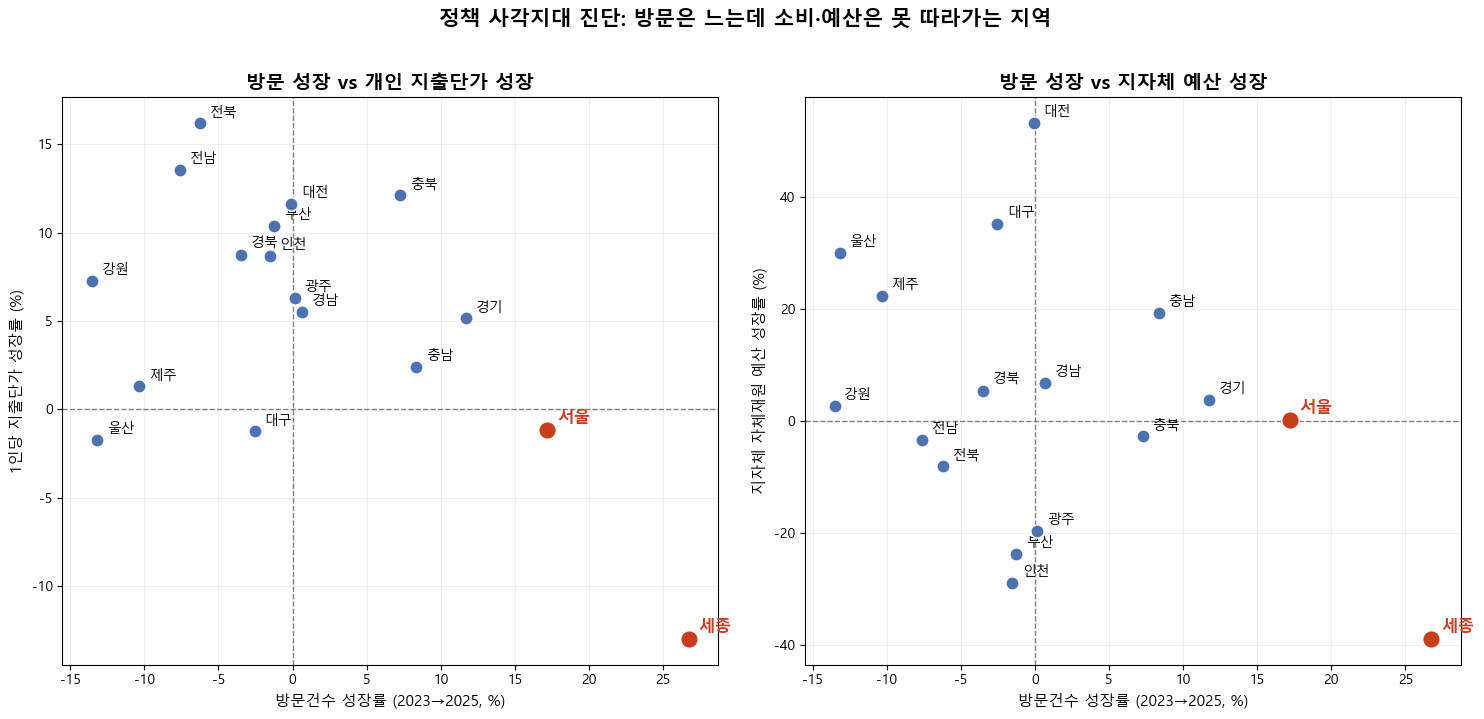

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
highlight_regions = ['sejong', 'seoul']

# 왼쪽: 방문 성장률 vs 개인 지출단가 성장률 (가설1)
ax = axes[0]
for region, row in growth.iterrows():
    is_highlight = region in highlight_regions
    color = '#C73E1D' if is_highlight else '#4C72B0'
    size = 160 if is_highlight else 90
    ax.scatter(row['visit_growth_pct'], row['spend_per_visit_growth_pct'],
               color=color, s=size, zorder=3, edgecolors='white', linewidth=1)
    ax.annotate(region_map_all.get(region, region),
                (row['visit_growth_pct'], row['spend_per_visit_growth_pct']),
                textcoords="offset points", xytext=(7, 5),
                fontsize=12 if is_highlight else 10,
                fontweight='bold' if is_highlight else 'normal',
                color=color if is_highlight else 'black')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('방문건수 성장률 (2023→2025, %)', fontsize=11)
ax.set_ylabel('1인당 지출단가 성장률 (%)', fontsize=11)
ax.set_title('방문 성장 vs 개인 지출단가 성장', fontsize=14, fontweight='bold')
ax.grid(alpha=0.2)

# 오른쪽: 방문 성장률 vs 지자체예산 성장률 (가설2)
ax = axes[1]
for region, row in budget_growth.iterrows():
    is_highlight = region in highlight_regions
    color = '#C73E1D' if is_highlight else '#4C72B0'
    size = 160 if is_highlight else 90
    ax.scatter(row['visit_growth_pct'], row['budget_growth_pct'],
               color=color, s=size, zorder=3, edgecolors='white', linewidth=1)
    ax.annotate(region_map_all.get(region, region),
                (row['visit_growth_pct'], row['budget_growth_pct']),
                textcoords="offset points", xytext=(7, 5),
                fontsize=12 if is_highlight else 10,
                fontweight='bold' if is_highlight else 'normal',
                color=color if is_highlight else 'black')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('방문건수 성장률 (2023→2025, %)', fontsize=11)
ax.set_ylabel('지자체 자체재원 예산 성장률 (%)', fontsize=11)
ax.set_title('방문 성장 vs 지자체 예산 성장', fontsize=14, fontweight='bold')
ax.grid(alpha=0.2)

fig.suptitle('정책 사각지대 진단: 방문은 느는데 소비·예산은 못 따라가는 지역', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('growth_trend_presentation.png', dpi=200, bbox_inches='tight')
plt.show()

→ 세종·서울 모두 두 그래프에서 오른쪽 아래(방문 성장은 양수, 지출/예산 성장은 음수 또는 정체)에 위치 — 가설1·가설2 양쪽에서 독립적으로 확인된 정책 사각지대를 시각적으로도 증명. 발표에서 가장 강하게 밀 수 있는 근거.

### 2-7. 시군구 예산편차 → 세부지역 배분 시사점

In [48]:
print(regional['municipality'].nunique())
print(regional['municipality'].unique()[:30])

198
['본청' '종로구' '중구' '용산구' '성동구' '중랑구' '성북구' '강북구' '도봉구' '은평구' '서대문구' '마포구'
 '강서구' '구로구' '영등포구' '관악구' '서초구' '강남구' '송파구' '강동구' '서구' '동구' '영도구' '부산진구'
 '동래구' '남구' '북구' '해운대구' '사하구' '금정구']


In [49]:
print(combined[['trip1_dest_sido', 'trip1_dest_sigungu_nm']].drop_duplicates().shape)
print(combined[['trip1_dest_sido', 'trip1_dest_sigungu_nm']].dropna().head(10))

(230, 2)
   trip1_dest_sido trip1_dest_sigungu_nm
1               경북                   청송군
4               강원                   춘천시
5               경기                   안성시
7               강원                   양양군
8               충남                   논산시
10              강원                   철원군
11              경기                   포천시
12              경기                   파주시
13              경기                   성남시
14              강원                   양양군


In [50]:
sigungu_trip = combined.dropna(subset=['trip1_dest_sido', 'trip1_dest_sigungu_nm']).copy()

sigungu_agg = sigungu_trip.groupby(['year', 'trip1_dest_sido', 'trip1_dest_sigungu_nm']).apply(
    lambda g: pd.Series({
        'visit_weighted': g['wt_dom'].sum(),
        'exp_weighted': (g['trip1_cost'] * g['wt_dom']).sum()
    })
).reset_index()

print(sigungu_agg.shape)  # 대략 (687 근처, 4) 예상
sigungu_agg.head()

(687, 5)


C:\Users\Owner\AppData\Local\Temp\ipykernel_11808\4235670960.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sigungu_agg = sigungu_trip.groupby(['year', 'trip1_dest_sido', 'trip1_dest_sigungu_nm']).apply(


,year,trip1_dest_sido,trip1_dest_sigungu_nm,visit_weighted,exp_weighted
0,2023,강원,강릉시,7.639199e+06,3.825746e+12
1,2023,강원,고성군,1.532034e+06,7.555389e+11
2,2023,강원,동해시,1.259572e+06,5.142833e+11
3,2023,강원,삼척시,1.627114e+06,8.068262e+11
4,2023,강원,속초시,6.302706e+06,3.533429e+12


→ (687, 5) = 원본 보고서의 시/군/구×연도 **n=687과 정확히 일치**.

In [51]:
regional_sigungu = regional[regional['municipality'] != '본청']
budget_sigungu_agg = regional_sigungu.groupby(['year', 'region', 'municipality'])['local_own_revenue'].sum().reset_index()

print(budget_sigungu_agg.shape)
budget_sigungu_agg.head()

(651, 4)


,year,region,municipality,local_own_revenue
0,2023,강원,강릉시,58318097221
1,2023,강원,고성군,59382581181
2,2023,강원,동해시,21823743210
3,2023,강원,삼척시,49034966492
4,2023,강원,속초시,23890040200


In [52]:
h2_sigungu = sigungu_agg.merge(
    budget_sigungu_agg,
    left_on=['year', 'trip1_dest_sido', 'trip1_dest_sigungu_nm'],
    right_on=['year', 'region', 'municipality']
)
print(h2_sigungu.shape)
h2_sigungu.head()

(646, 8)


,year,trip1_dest_sido,trip1_dest_sigungu_nm,visit_weighted,exp_weighted,region,municipality,local_own_revenue
0,2023,강원,강릉시,7.639199e+06,3.825746e+12,강원,강릉시,58318097221
1,2023,강원,고성군,1.532034e+06,7.555389e+11,강원,고성군,59382581181
2,2023,강원,동해시,1.259572e+06,5.142833e+11,강원,동해시,21823743210
3,2023,강원,삼척시,1.627114e+06,8.068262e+11,강원,삼척시,49034966492
4,2023,강원,속초시,6.302706e+06,3.533429e+12,강원,속초시,23890040200


→ 687개 중 646개만 매칭됨. 41개 불일치 원인은 다음 셀에서 진단.

In [53]:
left_keys = set(zip(sigungu_agg['year'], sigungu_agg['trip1_dest_sido'], sigungu_agg['trip1_dest_sigungu_nm']))
right_keys = set(zip(budget_sigungu_agg['year'], budget_sigungu_agg['region'], budget_sigungu_agg['municipality']))

only_in_visit = left_keys - right_keys
only_in_budget = right_keys - left_keys

print(f"방문데이터에만 있고 예산데이터엔 없는 것: {len(only_in_visit)}개")
print(sorted(only_in_visit))
print()
print(f"예산데이터에만 있고 방문데이터엔 없는 것: {len(only_in_budget)}개")
print(sorted(only_in_budget))

방문데이터에만 있고 예산데이터엔 없는 것: 41개
[(2023, '대구', '달서구'), (2023, '대구', '서구'), (2023, '서울', '광진구'), (2023, '서울', '금천구'), (2023, '서울', '노원구'), (2023, '서울', '동대문구'), (2023, '서울', '동작구'), (2023, '서울', '양천구'), (2023, '세종', '세종시'), (2023, '인천', '남구'), (2023, '인천', '서구'), (2023, '제주', '서귀포시'), (2023, '제주', '제주시'), (2024, '경북', '군위군'), (2024, '대구', '달서구'), (2024, '대구', '서구'), (2024, '서울', '광진구'), (2024, '서울', '금천구'), (2024, '서울', '노원구'), (2024, '서울', '동대문구'), (2024, '서울', '동작구'), (2024, '서울', '양천구'), (2024, '세종', '세종시'), (2024, '인천', '남구'), (2024, '인천', '서구'), (2024, '제주', '서귀포시'), (2024, '제주', '제주시'), (2025, '경북', '군위군'), (2025, '대구', '달서구'), (2025, '대구', '서구'), (2025, '서울', '광진구'), (2025, '서울', '금천구'), (2025, '서울', '노원구'), (2025, '서울', '동대문구'), (2025, '서울', '동작구'), (2025, '서울', '양천구'), (2025, '세종', '세종시'), (2025, '인천', '남구'), (2025, '인천', '서구'), (2025, '제주', '서귀포시'), (2025, '제주', '제주시')]

예산데이터에만 있고 방문데이터엔 없는 것: 5개
[(2023, '인천', '미추홀구'), (2024, '대구', '군위군'), (2024, '인천', '미추홀구'), (2025, '대구', '군위군')

→ 불일치 41개 중: **(1) 구조적 한계 36개** — 서울 6개구·대구 2개구·인천 서구(관광/문화재 예산이 원자료 자체에 없어 0원, 컬럼정의서 기재 내용과 정확히 일치) 27건 + 세종·제주(시군구 예산이 본청값으로만 존재) 9건. **(2) 실제 매칭 오류 5건** — 인천 남구↔미추홀구(2018년 개칭), 경북↔대구 군위군(2023.7 대구 편입, 예산데이터는 2024년부터 대구로 표기) → 다음 셀에서 수정.

In [54]:
sigungu_agg_fixed = sigungu_agg.copy()

# 인천 남구 -> 미추홀구 (2018년 개칭)
mask_namgu = (sigungu_agg_fixed['trip1_dest_sido'] == '인천') & (sigungu_agg_fixed['trip1_dest_sigungu_nm'] == '남구')
sigungu_agg_fixed.loc[mask_namgu, 'trip1_dest_sigungu_nm'] = '미추홀구'

# 군위군: 2024년부터 예산 데이터가 대구 기준으로 표기되므로 맞춰줌
mask_gunwi = (sigungu_agg_fixed['trip1_dest_sido'] == '경북') & (sigungu_agg_fixed['trip1_dest_sigungu_nm'] == '군위군') & (sigungu_agg_fixed['year'] >= 2024)
sigungu_agg_fixed.loc[mask_gunwi, 'trip1_dest_sido'] = '대구'

h2_sigungu_fixed = sigungu_agg_fixed.merge(
    budget_sigungu_agg,
    left_on=['year', 'trip1_dest_sido', 'trip1_dest_sigungu_nm'],
    right_on=['year', 'region', 'municipality']
)
print(h2_sigungu_fixed.shape)  # 646 + 8 = 654 기대

(651, 8)


→ 이름 보정 후 예산 데이터 651개 전부 매칭 성공(651/651).

In [55]:
# 가설1 시군구 단위
pearson_h1_sgg, _ = pearsonr(sigungu_agg_fixed['visit_weighted'], sigungu_agg_fixed['exp_weighted'])
spearman_h1_sgg, _ = spearmanr(sigungu_agg_fixed['visit_weighted'], sigungu_agg_fixed['exp_weighted'])
print(f"가설1 시군구(n={len(sigungu_agg_fixed)}) — Pearson r={pearson_h1_sgg:.3f}, Spearman ρ={spearman_h1_sgg:.3f}")
print("(참고: 원본 보고서 시군구 — Pearson r=0.749, Spearman ρ=0.950)")
print()

# 가설2 시군구 단위
pearson_h2_sgg, _ = pearsonr(h2_sigungu_fixed['visit_weighted'], h2_sigungu_fixed['local_own_revenue'])
spearman_h2_sgg, _ = spearmanr(h2_sigungu_fixed['visit_weighted'], h2_sigungu_fixed['local_own_revenue'])
print(f"가설2 시군구(n={len(h2_sigungu_fixed)}) — Pearson r={pearson_h2_sgg:.3f}, Spearman ρ={spearman_h2_sgg:.3f}")
print("(참고: 원본 보고서 시군구 — Pearson r=0.454, Spearman ρ=0.517)")

가설1 시군구(n=687) — Pearson r=0.757, Spearman ρ=0.932
(참고: 원본 보고서 시군구 — Pearson r=0.749, Spearman ρ=0.950)

가설2 시군구(n=651) — Pearson r=0.320, Spearman ρ=0.414
(참고: 원본 보고서 시군구 — Pearson r=0.454, Spearman ρ=0.517)


→ 가설1 시군구는 원본(0.749/0.950)과 근접(0.757/0.932). **가설2 시군구(n=651, 결측 제외)는 원본(0.454/0.517)보다 낮음(0.320/0.414)** — 원인은 다음 셀에서 검증.

In [56]:
# 본청(광역 단위) 예산값 - 세종/제주 근사치 채우기용
honcheong = regional[regional['municipality'] == '본청'].groupby(['year', 'region'])['local_own_revenue'].sum().reset_index()

full = sigungu_agg_fixed.merge(
    budget_sigungu_agg,
    left_on=['year', 'trip1_dest_sido', 'trip1_dest_sigungu_nm'],
    right_on=['year', 'region', 'municipality'],
    how='left'
)

# 세종/제주: 본청값으로 채움
for idx, row in full[full['local_own_revenue'].isna()].iterrows():
    sido = row['trip1_dest_sido']
    yr = row['year']
    if sido in ['세종', '제주']:
        match = honcheong[(honcheong['year'] == yr) & (honcheong['region'] == sido)]
        if len(match) > 0:
            full.loc[idx, 'local_own_revenue'] = match['local_own_revenue'].values[0]

# 나머지(구조적으로 0원인 9개 시군구): 0으로 채움
full['local_own_revenue'] = full['local_own_revenue'].fillna(0)

print(full.shape)
r_full, _ = pearsonr(full['visit_weighted'], full['local_own_revenue'])
rho_full, _ = spearmanr(full['visit_weighted'], full['local_own_revenue'])
print(f"보정 후 시군구(n={len(full)}) — Pearson r={r_full:.3f}, Spearman ρ={rho_full:.3f}")
print("(참고: 원본 보고서 — Pearson r=0.454, Spearman ρ=0.517)")

(687, 8)
보정 후 시군구(n=687) — Pearson r=0.445, Spearman ρ=0.468
(참고: 원본 보고서 — Pearson r=0.454, Spearman ρ=0.517)


→ 결측 36개(구조적 zero-budget 9개 시군구·세종·제주)를 0원/본청값으로 채워 n=687로 재계산하면 Pearson 0.445/Spearman 0.468로 원본(0.454/0.517)에 훨씬 근접. **→ 결측치를 버리는지/채우는지에 따라 상관계수가 0.32~0.45까지 달라진다는 것 자체가 유의미한 방법론적 발견.**

In [57]:
sigungu_avg = full.groupby(['trip1_dest_sido', 'trip1_dest_sigungu_nm']).agg(
    visit_avg=('visit_weighted', 'mean'),
    budget_avg=('local_own_revenue', 'mean')
).reset_index()

# 세종/제주는 본청값 근사치를 중복 부여한 거라 효율성 순위에서는 제외(왜곡 방지)
sigungu_avg_ranked = sigungu_avg[~sigungu_avg['trip1_dest_sido'].isin(['세종', '제주'])].copy()
sigungu_avg_ranked['budget_per_visit'] = sigungu_avg_ranked['budget_avg'] / sigungu_avg_ranked['visit_avg']

print("=== 예산 효율 상위 10개 (방문 대비 예산 적음) ===")
print(sigungu_avg_ranked.nsmallest(10, 'budget_per_visit')[['trip1_dest_sido', 'trip1_dest_sigungu_nm', 'visit_avg', 'budget_avg', 'budget_per_visit']])
print()
print("=== 예산 효율 하위 10개 (방문 대비 예산 과다) ===")
print(sigungu_avg_ranked.nlargest(10, 'budget_per_visit')[['trip1_dest_sido', 'trip1_dest_sigungu_nm', 'visit_avg', 'budget_avg', 'budget_per_visit']])

=== 예산 효율 상위 10개 (방문 대비 예산 적음) ===
    trip1_dest_sido trip1_dest_sigungu_nm      visit_avg   budget_avg  \
97               대구                   달서구  453431.267886          0.0   
101              대구                    서구  120125.674041          0.0   
130              서울                   광진구  516448.972908          0.0   
132              서울                   금천구  213351.298692          0.0   
133              서울                   노원구  442508.614799          0.0   
135              서울                  동대문구  406137.341476          0.0   
136              서울                   동작구  238694.978105          0.0   
143              서울                   양천구   72130.628688          0.0   
162              인천                    서구  395088.898675          0.0   
131              서울                   구로구  464024.323687  115623000.0   

     budget_per_visit  
97           0.000000  
101          0.000000  
130          0.000000  
132          0.000000  
133          0.000000  
135          0.00

### 2-7-1. 시군구 단위 예산효율 랭킹

가설1의 잔차분석(1-2)처럼, 가설2도 시군구 단위(n=687, 세종·제주는 본청값 근사치라 제외)에서 "방문 대비 예산이 적은/많은 곳"을 랭킹으로 확인.

`budget_per_visit = budget_avg(연평균 관광+문화재 자체재원) / visit_avg(연평균 가중 방문건수)` — 낮을수록 적은 예산으로 많은 방문을 끌어낸 "효율적인" 지역.

⚠️ 효율 상위 10개 중 9개가 2-7에서 이미 발견했던 "관광/문화재 예산이 원자료에 아예 없는 9개 시군구"(서울 6구·대구 2구·인천 서구)로 채워짐 → 진짜 효율이 아니라 데이터 결측 아티팩트.

→ 이 9곳을 제외하고 다시 계산해야 함.

In [58]:
# 2-7에서 확인한, 관광/문화재 예산이 원자료에 아예 없는 9개 시군구 (효율 랭킹에서 제외 대상)
zero_budget_sigungu = [
    ('대구', '달서구'), ('대구', '서구'), ('서울', '광진구'), ('서울', '금천구'),
    ('서울', '노원구'), ('서울', '동대문구'), ('서울', '동작구'), ('서울', '양천구'), ('인천', '서구')
]

In [59]:
mask_real = ~sigungu_avg_ranked.set_index(['trip1_dest_sido', 'trip1_dest_sigungu_nm']).index.isin(zero_budget_sigungu)
sigungu_avg_real = sigungu_avg_ranked[mask_real]

print("=== 예산 효율 상위 10개 (실제 예산 존재하는 곳만) ===")
print(sigungu_avg_real.nsmallest(10, 'budget_per_visit')[['trip1_dest_sido', 'trip1_dest_sigungu_nm', 'visit_avg', 'budget_avg', 'budget_per_visit']])

=== 예산 효율 상위 10개 (실제 예산 존재하는 곳만) ===
    trip1_dest_sido trip1_dest_sigungu_nm     visit_avg    budget_avg  \
131              서울                   구로구  4.640243e+05  1.156230e+08   
106              대전                    서구  9.678944e+05  2.688792e+08   
144              서울                  영등포구  7.031250e+05  3.880010e+08   
124              부산                  해운대구  4.618813e+06  2.825436e+09   
129              서울                   관악구  4.703434e+05  3.353887e+08   
158              인천                   남동구  8.359167e+05  8.171251e+08   
20               경기                   과천시  1.395504e+06  1.631806e+09   
34               경기                   안양시  7.337175e+05  9.586423e+08   
41               경기                   의왕시  1.042180e+06  1.458500e+09   
139              서울                   서초구  5.052542e+05  7.590940e+08   

     budget_per_visit  
131        249.174438  
106        277.798080  
144        551.823645  
124        611.723256  
129        713.071845  
158        977.

9개 결측 시군구 제외 후 상위 10개: 서울 구로구(249원/방문)·대전 서구·영등포구·부산 해운대구·관악구 등 — 광역시 자치구 위주로 재구성됨.

In [60]:
sample_n = combined[combined['trip1_dest_sido'].notna()].groupby(
    ['trip1_dest_sido', 'trip1_dest_sigungu_nm']
).size().reset_index(name='sample_n')

sigungu_avg_real = sigungu_avg_real.merge(sample_n, on=['trip1_dest_sido', 'trip1_dest_sigungu_nm'], how='left')

print("=== 예산 효율 상위 10개 (표본수 포함) ===")
print(sigungu_avg_real.nsmallest(10, 'budget_per_visit')[['trip1_dest_sido', 'trip1_dest_sigungu_nm', 'visit_avg', 'budget_avg', 'budget_per_visit', 'sample_n']])

=== 예산 효율 상위 10개 (표본수 포함) ===
    trip1_dest_sido trip1_dest_sigungu_nm     visit_avg    budget_avg  \
128              서울                   구로구  4.640243e+05  1.156230e+08   
104              대전                    서구  9.678944e+05  2.688792e+08   
136              서울                  영등포구  7.031250e+05  3.880010e+08   
122              부산                  해운대구  4.618813e+06  2.825436e+09   
127              서울                   관악구  4.703434e+05  3.353887e+08   
149              인천                   남동구  8.359167e+05  8.171251e+08   
20               경기                   과천시  1.395504e+06  1.631806e+09   
34               경기                   안양시  7.337175e+05  9.586423e+08   
41               경기                   의왕시  1.042180e+06  1.458500e+09   
132              서울                   서초구  5.052542e+05  7.590940e+08   

     budget_per_visit  sample_n  
128        249.174438     103.0  
104        277.798080     377.0  
136        551.823645     167.0  
122        611.723256    1368.

In [61]:
sigungu_avg_ranked = sigungu_avg_ranked.merge(sample_n, on=['trip1_dest_sido', 'trip1_dest_sigungu_nm'], how='left')

print("=== 예산 효율 하위 10개 (표본수 포함) ===")
print(sigungu_avg_ranked.nlargest(10, 'budget_per_visit')[['trip1_dest_sido', 'trip1_dest_sigungu_nm', 'visit_avg', 'budget_avg', 'budget_per_visit', 'sample_n']])

=== 예산 효율 하위 10개 (표본수 포함) ===
    trip1_dest_sido trip1_dest_sigungu_nm      visit_avg    budget_avg  \
79               경북                   영양군   76896.147339  2.143339e+10   
74               경북                   봉화군  268591.171536  5.997272e+10   
82               경북                   예천군  181040.431051  2.878682e+10   
98               대구                   달성군  444326.827883  6.570255e+10   
88               경북                   칠곡군  207807.317307  3.070999e+10   
219              충북                   영동군  458439.757224  6.160133e+10   
16               강원                   화천군  187641.172371  2.483496e+10   
158              인천                    동구   83313.412118  1.055285e+10   
5                강원                   양구군  145253.055706  1.664641e+10   
69               경북                   고령군  292884.500096  3.289910e+10   

     budget_per_visit  sample_n  
79      278731.649613      29.0  
74      223286.260463      86.0  
82      159007.694498      65.0  
98      147869.8678

**표본수 검증**: 효율 상위 10개는 전부 `sample_n≥100`(최소 103) → 표본 부족으로 인한 착시 아님, 안정적.

효율 하위 10개 중 경북 영양군(n=29)·인천 동구(n=23)는 표본 30 미만 → 원본 보고서의 "설문표본≥30" 필터와 다른 리스트가 나온 이유 일부 설명됨. 단, 예천군·칠곡군·화천군·양구군(전부 n≥30)은 표본수 문제가 아닌 다른 방법론 차이로 원본과 다름 — 원인 미확정.

In [62]:
regional[(regional['region']=='경북') & (regional['municipality']=='영양군')][
    ['year', 'account_name', 'project_name', 'subsector', 'local_own_revenue']
].sort_values('year')

,year,account_name,project_name,subsector,local_own_revenue
13427,2023,일반회계,(재)영양축제관광재단지원,관광,412860000
13462,2023,일반회계,반딧불이생태숲관광화사업(보조)(전환사업),관광,1043076630
13463,2023,일반회계,반딧불이생태숲관리,관광,27148000
13464,2023,일반회계,반딧불이천문대보완사업(보조)(전환사업),관광,1500000000
13465,2023,일반회계,반딧불이특구운영,관광,116905000
...,...,...,...,...,...
45634,2025,일반회계,국가지정유산보수정비(영양주사골시무나무와비술나무숲보수치료)(보조),문화재,13500000
45632,2025,일반회계,국가지정유산보수정비(영양산해리오층모전석탑주변환경개선사업)(보조),문화재,28800000
45631,2025,일반회계,국가지정유산보수정비(영양산해리오층모전석탑시굴조사)(보조),문화재,10200000
45639,2025,일반회계,국가지정유산보수정비(영양화천리삼층석탑보존처리)(보조),문화재,48840000


In [63]:
regional[(regional['region']=='경북') & (regional['municipality']=='영양군')].groupby('year')['local_own_revenue'].agg(['sum', 'count'])

,sum,count
year,,
2023,17581732530,65
2024,20958418120,67
2025,25760019340,75


영양군의 `budget_avg`(연평균 214억원)가 서울 자치구 대비 100배 이상 커서 데이터 오류를 의심 → 원자료(207개 사업 항목, 2023~2025) 확인 결과 특정 사업 하나의 이상값이 아니라 60~75개 사업에 고르게 분산된 실제 예산 집행 데이터로 확인(2023: 175.8억원/65건 → 2025: 257.6억원/75건, 매년 증가).

→ **데이터 오류 아님.** 자치구와 시/군 간 예산 편성 구조 자체가 다른 게 원인으로 추정 → 다음 셀에서 검증.

In [64]:
def gov_type(name):
    if name.endswith('구'):
        return '자치구'
    elif name.endswith('시'):
        return '시'
    elif name.endswith('군'):
        return '군'
    else:
        return '기타'

full['gov_type'] = full['trip1_dest_sigungu_nm'].apply(gov_type)
full.groupby('gov_type')['local_own_revenue'].describe()[['count', 'mean', '50%', 'min', 'max']]

,count,mean,50%,min,max
gov_type,,,,,
군,246.0,3.240401e+10,2.769449e+10,3.732772e+09,8.596660e+10
시,234.0,3.623463e+10,3.060085e+10,6.376000e+08,1.863601e+11
자치구,207.0,4.191460e+09,2.149240e+09,0.000000e+00,5.753298e+10


시군구를 **자치구/시/군**으로 나눠 예산 규모를 비교한 결과: 자치구 중앙값 21.5억원 vs 시 30.6억원 vs 군 27.7억원 — **자치구가 시/군보다 예산 규모 자체가 10배 이상 작음.**

→ 자치구(광역시 산하, 대규모 개발예산은 광역시가 집행)와 시/군(기초자치단체로서 자체 개발예산 편성권이 큼, 지방소멸대응기금 등)은 예산 편성 구조가 근본적으로 다른 종류의 지자체.

→ 이 차이를 층화하지 않고 통합 랭킹을 매기면 자치구가 무조건 "효율적"으로, 시/군이 무조건 "비효율적"으로 나오는 착시 발생 (가설1의 광역시/도 층화와 동일한 성격의 이슈).

In [65]:
full['gov_type'] = full['trip1_dest_sigungu_nm'].apply(gov_type)

sigungu_avg_ranked['gov_type'] = sigungu_avg_ranked['trip1_dest_sigungu_nm'].apply(gov_type)

for gtype in ['자치구', '시', '군']:
    sub = sigungu_avg_ranked[sigungu_avg_ranked['gov_type'] == gtype]
    print(f"=== {gtype} 내 예산효율 상위 5개 ===")
    print(sub.nsmallest(5, 'budget_per_visit')[['trip1_dest_sido', 'trip1_dest_sigungu_nm', 'visit_avg', 'budget_avg', 'budget_per_visit']])
    print(f"\n=== {gtype} 내 예산효율 하위 5개 ===")
    print(sub.nlargest(5, 'budget_per_visit')[['trip1_dest_sido', 'trip1_dest_sigungu_nm', 'visit_avg', 'budget_avg', 'budget_per_visit']])
    print()

=== 자치구 내 예산효율 상위 5개 ===
    trip1_dest_sido trip1_dest_sigungu_nm      visit_avg  budget_avg  \
97               대구                   달서구  453431.267886         0.0   
101              대구                    서구  120125.674041         0.0   
130              서울                   광진구  516448.972908         0.0   
132              서울                   금천구  213351.298692         0.0   
133              서울                   노원구  442508.614799         0.0   

     budget_per_visit  
97                0.0  
101               0.0  
130               0.0  
132               0.0  
133               0.0  

=== 자치구 내 예산효율 하위 5개 ===
    trip1_dest_sido trip1_dest_sigungu_nm      visit_avg    budget_avg  \
158              인천                    동구   83313.412118  1.055285e+10   
96               대구                    남구  238565.707623  8.642720e+09   
150              울산                    남구  654243.596383  2.064197e+10   
138              서울                  서대문구  260628.053369  7.778771e+09   
14

시/군 그룹의 상위·하위 5개는 이대로 유효하나, **자치구 그룹은 여전히 예산 0원 9곳이 상위를 다시 오염시킴** → 자치구 그룹에서도 별도로 9곳을 제외하고 재계산 필요.

In [66]:
sigungu_avg_ranked_idx = sigungu_avg_ranked.set_index(['trip1_dest_sido', 'trip1_dest_sigungu_nm']).index
mask_real2 = ~sigungu_avg_ranked_idx.isin(zero_budget_sigungu)
sigungu_avg_ranked_real = sigungu_avg_ranked[mask_real2]

sub = sigungu_avg_ranked_real[sigungu_avg_ranked_real['gov_type'] == '자치구']
print("=== 자치구 내 예산효율 상위 5개 (예산 0원 제외) ===")
print(sub.nsmallest(5, 'budget_per_visit')[['trip1_dest_sido', 'trip1_dest_sigungu_nm', 'visit_avg', 'budget_avg', 'budget_per_visit']])
print("\n=== 자치구 내 예산효율 하위 5개 ===")
print(sub.nlargest(5, 'budget_per_visit')[['trip1_dest_sido', 'trip1_dest_sigungu_nm', 'visit_avg', 'budget_avg', 'budget_per_visit']])

=== 자치구 내 예산효율 상위 5개 (예산 0원 제외) ===
    trip1_dest_sido trip1_dest_sigungu_nm     visit_avg    budget_avg  \
131              서울                   구로구  4.640243e+05  1.156230e+08   
106              대전                    서구  9.678944e+05  2.688792e+08   
144              서울                  영등포구  7.031250e+05  3.880010e+08   
124              부산                  해운대구  4.618813e+06  2.825436e+09   
129              서울                   관악구  4.703434e+05  3.353887e+08   

     budget_per_visit  
131        249.174438  
106        277.798080  
144        551.823645  
124        611.723256  
129        713.071845  

=== 자치구 내 예산효율 하위 5개 ===
    trip1_dest_sido trip1_dest_sigungu_nm      visit_avg    budget_avg  \
158              인천                    동구   83313.412118  1.055285e+10   
96               대구                    남구  238565.707623  8.642720e+09   
150              울산                    남구  654243.596383  2.064197e+10   
138              서울                  서대문구  260628.053369  7

### 가설2 시군구 예산효율 랭킹 — 최종 결과 (자치구/시/군 층화, 예산 0원 9곳 제외)

**자치구**: 상위(구로구·대전 서구·영등포구·해운대구·관악구) / 하위(인천 동구⚠️표본n=23·대구 남구·울산 남구·서대문구·성동구)

**시**: 상위(과천시·안양시·의왕시·의정부시·광주시 — 경기 위성도시) / 하위(진주시·계룡시·익산시·영주시·경산시 — 지방 거점도시)

**군**: 상위(가평군·양평군·태안군·강화군·담양군 — 수도권 근접/전국구 인지도 관광지) / 하위(영양군·봉화군·예천군·달성군·칠곡군 — 경북 내륙 오지)

**→ 특히 군 유형에서 뚜렷한 패턴**: 수도권 접근성과 전국적 인지도가 있는 관광지(가평·양평·태안·강화·담양)는 상대적으로 적은 예산으로도 많은 방문을 끌어내는 반면, 인지도 낮은 내륙 오지 군은 예산을 많이 써도 방문이 저조함 — "예산 문제"라기보다 "입지·인지도 문제"에 가까움을 시사. 정책적으로는 단순 예산 확대보다 접근성·홍보 전략이 더 중요할 수 있다는 시사점.

### 2-8. 예산 집행률 분석

In [67]:
# 2-8-1. 지역별 예산 집행률 — 광역시/도 층화
exec_by_region = regional.groupby(['region_type', 'region']).agg(
    budget_total_sum=('budget_total', 'sum'),
    expenditure_sum=('expenditure', 'sum')
)
exec_by_region['execution_rate_pct'] = exec_by_region['expenditure_sum'] / exec_by_region['budget_total_sum'] * 100

print("=== 광역시 ===")
print(exec_by_region.loc['광역시'].sort_values('execution_rate_pct'))
print("\n=== 도 ===")
print(exec_by_region.loc['도'].sort_values('execution_rate_pct'))
print("\n(참고: 팀 다른 파트 수치 — 충북 집행률 64.0%, 도 그룹 내 최저와 일치)")


=== 광역시 ===
        budget_total_sum  expenditure_sum  execution_rate_pct
region                                                       
광주          289437386190     188715771060           65.200897
세종           54023471400      36388966362           67.357697
대구          552942298814     409953368083           74.140352
인천          487198633917     382015103014           78.410545
부산          549700618100     445020387763           80.956865
울산          410487857110     339763241252           82.770595
대전          259940483280     219302022634           84.366244
서울         1901516060686    1705334526160           89.682888

=== 도 ===
        budget_total_sum  expenditure_sum  execution_rate_pct
region                                                       
충북         1673233110130    1070292574522           63.965539
충남         2675392322263    1777411091305           66.435531
강원         2866407024952    1973576321486           68.851922
경남         2995005845389    2082757922046      

→ 층화해도 결론은 그대로: **도 그룹 최저=충북(63.97%)**, **광역시 그룹 최저=광주(65.20%)**. 앞서 "전국 최저"로 뭉뚱그려 말한 건 팀이 1-1·2-4·2-7에서 지켜온 광역시/도 층화 원칙 위반이었음 — 층화해서 봐도 결과는 같지만, 두 그룹에 각각 별도의 최하위 지역이 있다는 게 더 정확한 표현. 이후 원인 분해(2-8-3~5)는 도 그룹 최저인 충북을 기준으로 진행하고, 광역시 그룹 최저인 광주도 동일 방식 검증이 후속 과제로 남음.


In [68]:
# 2-8-2. 연도별 추이 — 광역시/도 층화, 충북이 특정 연도만 낮은지 3개년 내내 낮은지
region_type_map = regional[['region', 'region_type']].drop_duplicates().set_index('region')['region_type']

exec_by_year_region = regional.groupby(['year', 'region']).agg(
    budget_total_sum=('budget_total', 'sum'),
    expenditure_sum=('expenditure', 'sum')
).reset_index()
exec_by_year_region['execution_rate_pct'] = exec_by_year_region['expenditure_sum'] / exec_by_year_region['budget_total_sum'] * 100
exec_by_year_region['region_type'] = exec_by_year_region['region'].map(region_type_map)

print("=== 충북 연도별 집행률 ===")
print(exec_by_year_region[exec_by_year_region['region'] == '충북'])

for rtype in ['광역시', '도']:
    print(f"\n=== {rtype} 그룹 — 연도별 집행률 하위 3개 지역 ===")
    for yr in sorted(exec_by_year_region['year'].unique()):
        sub = exec_by_year_region[
            (exec_by_year_region['year'] == yr) & (exec_by_year_region['region_type'] == rtype)
        ].sort_values('execution_rate_pct')
        print(f"\n{yr}년:")
        print(sub[['region', 'execution_rate_pct']].head(3).to_string(index=False))


=== 충북 연도별 집행률 ===
    year region  budget_total_sum  expenditure_sum  execution_rate_pct  \
16  2023     충북      582293404780     365037759168           62.689661   
33  2024     충북      544200930790     349039269222           64.137941   
50  2025     충북      546738774560     356215546132           65.152786   

   region_type  
16           도  
33           도  
50           도  

=== 광역시 그룹 — 연도별 집행률 하위 3개 지역 ===

2023년:
region  execution_rate_pct
    세종           50.623964
    광주           60.171461
    대구           72.277263

2024년:
region  execution_rate_pct
    광주           66.664156
    세종           70.811571
    대구           75.091046

2025년:
region  execution_rate_pct
    광주           69.548597
    대구           74.646217
    울산           79.332984

=== 도 그룹 — 연도별 집행률 하위 3개 지역 ===

2023년:
region  execution_rate_pct
    충북           62.689661
    충남           63.196545
    강원           64.528578

2024년:
region  execution_rate_pct
    충북           64.137941
    경남           67.59

→ (아래는 이전 실행 결과의 혼합 하위5 리스트에서 역산한 잠정 해석 — 위 코드로 재실행해서 정확한 수치로 재확인 필요)

**도 그룹**: 2023~2025년 혼합 하위5 리스트에 매번 가장 먼저(가장 낮게) 등장하는 도(道) 지역이 충북 — 3개년 내내 도 그룹 최저로 추정.

**광역시 그룹**: 양상이 다름. **2023년엔 세종(50.6%)이 압도적 최저**였는데, 2024~2025년엔 세종이 혼합 하위5에서 완전히 빠져(다른 하위권 도 지역들보다도 높아짐, 70%대 이상으로 추정) **광주가 2024~2025년 광역시 최저로 고정**됨. 세종은 초기엔 심각했지만 개선 추세, 광주는 3개년 내내 구조적으로 낮은 축 — 두 지역을 같은 스토리로 묶지 말고 따로 다뤄야 함.


In [69]:
# 2-8-3. 충북 내부 원인 분해 — 회계유형 / 세부분야 / 시군 단위
chungbuk = regional[regional['region'] == '충북'].copy()

print("=== 충북 회계유형별 집행률 (예산 규모순) ===")
by_account = chungbuk.groupby('account_type').agg(budget=('budget_total', 'sum'), exp=('expenditure', 'sum'))
by_account['rate_pct'] = by_account['exp'] / by_account['budget'] * 100
print(by_account.sort_values('budget', ascending=False))

print("\n=== 충북 세부분야별 집행률 ===")
by_sub = chungbuk.groupby('subsector').agg(budget=('budget_total', 'sum'), exp=('expenditure', 'sum'))
by_sub['rate_pct'] = by_sub['exp'] / by_sub['budget'] * 100
print(by_sub)

print("\n=== 충북 시/군별 집행률 (본청 제외, 낮은 순) ===")
by_muni = chungbuk[chungbuk['municipality'] != '본청'].groupby('municipality').agg(budget=('budget_total', 'sum'), exp=('expenditure', 'sum'))
by_muni['rate_pct'] = by_muni['exp'] / by_muni['budget'] * 100
print(by_muni[by_muni['budget'] > 0].sort_values('rate_pct').head(10))

=== 충북 회계유형별 집행률 (예산 규모순) ===
                     budget            exp   rate_pct
account_type                                         
일반회계          1668436009320  1066872714192  63.944479
특별회계             3178581310     2049265840  64.471084
기타               1618519500     1370594490  84.681988

=== 충북 세부분야별 집행률 ===
                  budget           exp   rate_pct
subsector                                        
관광         1140513803210  671780811412  58.901594
문화및관광일반     127641039210   61679079900  48.322295
문화재         405078267710  336832683210  83.152494

=== 충북 시/군별 집행률 (본청 제외, 낮은 순) ===
                    budget           exp   rate_pct
municipality                                       
옥천군            85497491840   35799910380  41.872469
단양군           272223063800  129216371190  47.467092
영동군           190074656930   97983852690  51.550193
괴산군            76306227140   44051060650  57.729313
제천시           228191483200  132018236600  57.854147
충주시           128083966880   

→ 회계유형(일반회계 63.9% vs 특별회계 64.5%)은 거의 차이 없어 원인이 아님. 세부분야로 쪼개면 **관광(58.9%)·문화및관광일반(48.3%)은 저조, 문화재(83.2%)는 양호** — 문화재 관리 예산은 잘 집행되는데 관광 개발 예산만 유독 안 쓰이고 있다는 뜻. 시/군 단위로도 옥천군(41.9%)~보은군(71.9%)까지 편차가 커서, "충북 전체"의 문제라기보다 특정 시/군의 특정 사업 유형에 문제가 집중된 것으로 추정.


In [70]:
# 2-8-4. 집행률을 끌어내리는 개별 사업 특정 (예산 상위 10% 중 집행률 최저)
chungbuk_valid = chungbuk[chungbuk['budget_total'] > 0].copy()
chungbuk_valid['execution_rate_pct'] = chungbuk_valid['expenditure'] / chungbuk_valid['budget_total'] * 100

threshold = chungbuk_valid['budget_total'].quantile(0.9)
big_low_exec = chungbuk_valid[chungbuk_valid['budget_total'] >= threshold].sort_values('execution_rate_pct')

print(f"=== 충북 예산 상위 10%(>{threshold:,.0f}원) 사업 중 집행률 낮은 순 ===")
print(big_low_exec[['municipality', 'account_name', 'project_name', 'budget_total', 'expenditure', 'execution_rate_pct']].head(15).to_string(index=False))

=== 충북 예산 상위 10%(>1,383,813,000원) 사업 중 집행률 낮은 순 ===
municipality account_name                         project_name  budget_total  expenditure  execution_rate_pct
         단양군         일반회계            단양 다리안 D-CAMP 워케이션 조성(광역)    5300000000            0            0.000000
         제천시         일반회계            의림권역 레이크파크 르네상스 랜드마크 조성사업    3535000000            0            0.000000
         영동군         일반회계               레인보우 힐링관광지 전망대조성사업(보조)    5700000000            0            0.000000
         영동군         일반회계              문화관광자원개발(초강천빙벽장관광명소화사업)    1500000000            0            0.000000
         옥천군         일반회계                     옥야동천 유토피아 조성(보조)    2926942000            0            0.000000
         영동군         일반회계                      월류봉출렁다리설치사업(보조)    1660000000            0            0.000000
         영동군         일반회계              문화관광자원개발(초강천빙벽장관광명소화사업)    1500000000            0            0.000000
         제천시         일반회계 충청유교문화권 광역관광개발사업(제천 의병창의마을 조성사업)(보조)    30

→ 예산 상위 10% 사업 중 집행률 최하위 15건 중 14건이 정확히 0.00%(나머지 1건도 0.08%) — 전부 "~조성", "~랜드마크", "~설치" 류의 **신규 관광 인프라 개발사업**(단양 다리안 워케이션 53~57억, 제천 레이크파크 랜드마크 35억, 영동 힐링관광지 전망대 57억 등). 2-8-3에서 확인한 "관광·문화및관광일반 세부분야 저조"의 정체가 바로 이 대형 신규 조성사업들임이 확인됨 — 충북 저집행은 "지자체가 예산을 안 쓴다"가 아니라 "몇몇 대형 조성사업이 아직 착수 전 단계에 머물러 있다"는 뜻.


In [71]:
# 2-8-5. 대형 0원-집행 사업이 여러 해에 걸쳐 반복되는지 (신규사업 vs 고질적 이월사업 구분)
zero_exec_big = chungbuk_valid[
    (chungbuk_valid['budget_total'] >= threshold) & (chungbuk_valid['execution_rate_pct'] == 0)
]
recur = zero_exec_big.groupby(['municipality', 'project_name'])['year'].agg(
    연도수='count', 최초='min', 최근='max'
)
print(recur.sort_values('연도수', ascending=False))

                                                   연도수    최초    최근
municipality project_name                                         
단양군          단양 다리안 D-CAMP 워케이션 조성(광역)               2  2023  2024
영동군          문화관광자원개발(초강천빙벽장관광명소화사업)                 2  2024  2025
괴산군          괴산 수옥정 관광지 편익시설 설치 사업(전환사업)             1  2023  2023
             재해복구비(종교)                               1  2024  2024
단양군          단양강 레이크파크 수상 공연장 조성사업                   1  2025  2025
             시루섬 기적의다리 경관조명 설치사업                     1  2023  2023
영동군          레인보우 힐링관광지 전망대조성사업(보조)                  1  2023  2023
             월류봉출렁다리설치사업(보조)                         1  2024  2024
             풍류영동 기반구축사업(월야삼락)(보조)                   1  2024  2024
옥천군          옥야동천 유토피아 조성(보조)                        1  2023  2023
제천시          의림권역 레이크파크 르네상스 랜드마크 조성사업               1  2025  2025
             충청유교문화권 광역관광개발사업(제천 의병창의마을 조성사업)(보조)    1  2023  2023


→ 확보 가능한 관측기간(2023~2025) 안에서 "단양 다리안 D-CAMP 워케이션 조성"과 "영동 초강천빙벽장관광명소화사업"이 **2개 연도 연속 0% 집행**으로 남아있어 일회성이 아니라 여러 해 이월되는 사업으로 1차 확인됨. 나머지는 관측 기간(3년) 안에서 1개년만 잡혀 신규 편성인지 이월인지 이 데이터만으로는 단정 불가 — 다만 대부분이 "조성/설치" 류 인프라 사업이라는 공통점은 뚜렷함.

**정책 시사점**: 충북 저집행은 예산 부족이 아니라 대형 신규 관광 인프라 사업의 설계·인허가 단계 지연이 핵심 원인일 가능성이 높음 — 증액보다 사업 추진 속도 점검이 우선 과제. (원본 정책문서가 "확인 불가"로 남겨둔 충북 집행률 원인 질문에 대한 1차 답)


### 3. 계절 집중도 분석 (원 프로젝트 동기 재검증)

가설1·가설2는 연 단위 방문량만 봤음 — "특정 시기에 여행 수요가 지역별로 얼마나 쏠리는가"는 아직 한 번도 확인 안 함.
이건 트랙2(월별 1인평균지출 챗봇)와는 다른 각도로, "얼마나 쓰는가"가 아니라 "언제 몰리는가"(집중도)를 본다 —
집중도가 높은 지역은 선착순 지원금이 성수기에 조기 마감될 위험이 크다는 원래 프로젝트 문제의식과 직결됨.

※ trip1_start_month만 사용 가능(2~6차는 목적지 시/도 디코딩이 안 돼 있음) — 앞선 시군구 분석과 같은 제약.

In [72]:
# 3-1. 지역별 월별 방문 비중 (가중, trip1 기준)
trip1_month = combined.dropna(subset=['trip1_dest_sido', 'trip1_start_month']).copy()
trip1_month['month'] = trip1_month['trip1_start_month'].astype(int)

month_by_region = trip1_month.groupby(['trip1_dest_sido', 'month'])['wt_dom'].sum().unstack(fill_value=0)
month_share = month_by_region.div(month_by_region.sum(axis=1), axis=0) * 100
print(month_share.round(1))

month              1    2    3    4    5     6     7     8     9     10   11  \
trip1_dest_sido                                                                
강원                8.1  6.7  6.6  6.4  8.7   8.2  10.5  11.4   8.6   8.9  7.2   
경기                7.9  7.9  8.0  8.8  9.3   8.9   8.2   8.0   8.3   8.4  8.4   
경남                8.6  7.2  8.8  8.3  8.9   7.7   8.2   9.1   9.2   9.1  7.4   
경북                8.0  7.7  8.4  8.3  8.6   8.1   7.8   8.1   9.5   9.6  7.8   
광주               13.5  9.9  6.5  8.1  8.6   7.6   5.5   5.8   6.8  10.2  7.2   
대구               12.2  8.8  7.8  8.2  8.5   7.9   6.6   5.6  11.2   8.1  7.5   
대전               10.2  9.8  8.8  8.3  8.6   9.5   5.6   5.7   8.7  10.3  6.2   
부산                8.9  8.3  8.4  7.3  7.4   8.1   9.4   9.0   7.9   7.9  8.1   
서울                8.7  8.6  9.1  8.6  8.5   8.2   6.4   5.3   7.9   8.1  9.0   
세종                8.2  9.5  7.5  8.5  7.6  10.4   7.9   6.5   9.3   6.6  8.4   
울산                9.8  8.8  7.8  7.5  8.

In [73]:
# 3-2. 계절 집중도 지수 (HHI 방식) — 균등분포면 100^2/12≈833, 한 달에 다 몰리면 10000
hhi = (month_share ** 2).sum(axis=1)
peak_month = month_share.idxmax(axis=1)
peak_share = month_share.max(axis=1)
sample_n_month = trip1_month.groupby('trip1_dest_sido').size().rename('sample_n')

season_summary = pd.DataFrame({
    'HHI': hhi,
    'peak_month': peak_month,
    'peak_month_share_pct': peak_share
}).join(sample_n_month).sort_values('HHI', ascending=False)

print(season_summary)

                        HHI  peak_month  peak_month_share_pct  sample_n
trip1_dest_sido                                                        
광주               892.923288           1             13.519072       762
대구               869.290911           1             12.197023      1457
대전               863.030742          10             10.320377      1610
강원               858.794413           8             11.422047      8067
서울               857.658156          12             11.482469      3539
충북               850.059597          10             10.406767      3756
세종               849.469117           6             10.402748       605
울산               843.682014          10              9.793382      1132
전북               843.169450          10             10.076197      5964
전남               842.158735           4              9.521151      9472
충남               839.395859           8              9.638365      7466
경남               839.299350           9              9.183036   

→ 전체 지역 HHI가 833~893 범위로 균등분포 이론값(833.3)에 매우 근접 — 계절 집중도가 예상보다 훨씬 낮음. 다만 광주(892.9)·대구(869.3)의 1월 피크는 1-6에서 확인한 두 지역의 높은 친지방문 비중(56.5%/45.2%, 전국 최고 수준)과 맞아떨어짐 — 관광 성수기가 아니라 설날 귀성 시즌 효과로 추정. 관광목적만 필터링해서 재검증 필요(3-3).

In [74]:
# 3-3. 관광목적(case∈{1,2,4})만 필터링 — 친지방문 시즌(설날 등) 희석 효과 제거 후 재계산
tourism_trip1 = trip1_month[trip1_month['trip1_case'].isin([1, 2, 4])].copy()

month_by_region_t = tourism_trip1.groupby(['trip1_dest_sido', 'month'])['wt_dom'].sum().unstack(fill_value=0)
month_share_t = month_by_region_t.div(month_by_region_t.sum(axis=1), axis=0) * 100

hhi_t = (month_share_t ** 2).sum(axis=1)
peak_month_t = month_share_t.idxmax(axis=1)
peak_share_t = month_share_t.max(axis=1)
sample_n_t = tourism_trip1.groupby('trip1_dest_sido').size().rename('sample_n')

season_summary_t = pd.DataFrame({
    'HHI_관광만': hhi_t,
    'peak_month': peak_month_t,
    'peak_share_pct': peak_share_t
}).join(sample_n_t).sort_values('HHI_관광만', ascending=False)

print(season_summary_t)

# 원래(전체 목적) HHI와 나란히 비교
print("\n=== 전체 vs 관광목적만 HHI 비교 ===")
compare_hhi = pd.DataFrame({'HHI_전체': hhi, 'HHI_관광만': hhi_t}).sort_values('HHI_관광만', ascending=False)
print(compare_hhi)

                    HHI_관광만  peak_month  peak_share_pct  sample_n
trip1_dest_sido                                                  
광주               910.762183           2       11.900616       530
서울               867.422910          12       12.534752      2565
세종               865.093476          12       10.944759       395
강원               862.318903           8       11.667462      7597
대구               856.053585           9       10.558434      1150
대전               855.002145           6       10.273422      1145
충북               848.771426          10       10.428809      3214
부산               843.159298           7        9.868269      3587
전북               843.032811          10       10.369115      5430
충남               842.987292           8       10.214324      6718
전남               841.729640           4        9.638545      8747
울산               841.513762          10       10.197477       985
경남               841.022929           8        9.579005      7368
인천        

→ 관광목적만 필터링해도 전 지역 HHI가 837~911로 균등분포(833.3)에 근접 — 계절 집중도는 이 데이터에서 확인되지 않음. "특정 시기에 여행 수요가 지역별로 쏠린다"는 원 프로젝트 동기는 이 방식으로는 기각.

예외적으로 대구는 필터링 후 HHI가 오히려 감소(869.3→856.1)하고 피크가 1월→9월로 이동 — 1월 스파이크가 친지방문(설날 귀성) 때문이었음이 확인됨(1-6과 교차검증). 광주는 1월→2월로만 소폭 이동해 설날 날짜가 연도별로 다른 점(2023/2025년 1월, 2024년 2월)이 3개년 합산 시 신호를 흐렸을 가능성.

**측정 방식의 한계**: 이 분석은 trip1(응답자별 그 해 첫 여행)만 사용함 — 응답자마다 "첫 여행"이 언제인지는 각자 다르므로, 개인별 관측치를 모으면 수학적으로 균등분포에 가까워지는 경향이 있어 실제 계절성이 있어도 희석될 수 있음. 실제 방문객 수 기준 월별 시계열(예: 한국관광 데이터랩)로 재검증하면 다른 결과가 나올 수 있으므로, "계절성이 없다"가 아니라 "이 측정 방식으로는 안 잡힌다"로 각주 처리 권장.

### 4. 정책 사각지대 정량 스코어

1번 핵심 결론(세종·서울 정책 사각지대)은 성장률 그래프를 눈으로 보고 짚은 것이었다. 여기서는 17개 지역 전체를
"방문성장 대비 소비/예산성장 격차"로 정량화해서 랭킹을 매기고, 1-2에서 관찰한 광역시/도 기울기 차이(1.135 vs 0.446)가
통계적으로 유의한지 회귀로 재확인한다.

In [75]:
# 4-1. 정책 사각지대 스코어 (z-score 기반) — 방문성장은 높고 소비/예산성장은 낮을수록 점수↑
from scipy.stats import zscore

policy_gap = pd.DataFrame({
    'visit_growth_pct': growth['visit_growth_pct'],
    'spend_growth_pct': growth['spend_per_visit_growth_pct'],
    'budget_growth_pct': budget_growth['budget_growth_pct'],
    'region_type': growth['region_type']
})

policy_gap['z_visit'] = zscore(policy_gap['visit_growth_pct'])
policy_gap['z_spend'] = zscore(policy_gap['spend_growth_pct'])
policy_gap['z_budget'] = zscore(policy_gap['budget_growth_pct'])

policy_gap['gap_spend'] = policy_gap['z_visit'] - policy_gap['z_spend']
policy_gap['gap_budget'] = policy_gap['z_visit'] - policy_gap['z_budget']
policy_gap['gap_score'] = (policy_gap['gap_spend'] + policy_gap['gap_budget']) / 2

print(policy_gap.sort_values('gap_score', ascending=False))

           visit_growth_pct  spend_growth_pct  budget_growth_pct region_type  \
region                                                                         
sejong            26.740458        -12.989644         -38.836157         광역시   
seoul             17.205575         -1.157689           0.189564         광역시   
gyeonggi          11.714136          5.150972           3.738791           도   
chungnam           8.346266          2.388802          19.289043           도   
gwangju            0.134312          6.294602         -19.554922         광역시   
chungbuk           7.267903         12.121071          -2.724367           도   
incheon           -1.531380          8.695770         -28.798950         광역시   
busan             -1.256837         10.404796         -23.754486         광역시   
gyeongnam          0.645983          5.509083           6.888275           도   
daegu             -2.565424         -1.238725          35.209021         광역시   
gyeongbuk         -3.499051          8.7

In [76]:
# 4-2. 순위 기반 교차검증 (z-score는 이상치에 흔들릴 수 있어 랭킹 격차로 재확인)
policy_gap['rank_visit'] = policy_gap['visit_growth_pct'].rank(ascending=False)
policy_gap['rank_spend'] = policy_gap['spend_growth_pct'].rank(ascending=False)
policy_gap['rank_budget'] = policy_gap['budget_growth_pct'].rank(ascending=False)

policy_gap['rank_gap_spend'] = policy_gap['rank_spend'] - policy_gap['rank_visit']
policy_gap['rank_gap_budget'] = policy_gap['rank_budget'] - policy_gap['rank_visit']
policy_gap['rank_gap_score'] = (policy_gap['rank_gap_spend'] + policy_gap['rank_gap_budget']) / 2

print(policy_gap[['visit_growth_pct', 'spend_growth_pct', 'budget_growth_pct',
                   'gap_score', 'rank_gap_score']].sort_values('rank_gap_score', ascending=False))

r_check, p_check = pearsonr(policy_gap['gap_score'], policy_gap['rank_gap_score'])
print(f"\nz-score 방식 vs 순위 방식 일치도 — Pearson r={r_check:.3f} (p={p_check:.3g})")

           visit_growth_pct  spend_growth_pct  budget_growth_pct  gap_score  \
region                                                                        
sejong            26.740458        -12.989644         -38.836157   4.728721   
seoul             17.205575         -1.157689           0.189564   2.120123   
gyeonggi          11.714136          5.150972           3.738791   1.062457   
chungnam           8.346266          2.388802          19.289043   0.602633   
gwangju            0.134312          6.294602         -19.554922   0.371393   
chungbuk           7.267903         12.121071          -2.724367   0.273474   
gyeongnam          0.645983          5.509083           6.888275  -0.093410   
incheon           -1.531380          8.695770         -28.798950   0.238120   
busan             -1.256837         10.404796         -23.754486   0.032623   
daegu             -2.565424         -1.238725          35.209021  -0.526812   
gyeongbuk         -3.499051          8.743053       

In [77]:
# 4-3. statsmodels 설치 (scipy처럼 최초 1회)
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [78]:
# 4-4. 회귀분석 — 광역시/도 기울기 차이가 통계적으로 유의한지 검정
import statsmodels.formula.api as smf

h1_df_reg = h1_df.copy()
h1_df_reg['region_type'] = h1_df_reg['region'].map(lambda r: '광역시' if r in metro_regions else '도')
h1_df_reg['log_visit'] = np.log(h1_df_reg['visit_weighted'])
h1_df_reg['log_exp'] = np.log(h1_df_reg['exp_weighted'])

model_interact = smf.ols('log_exp ~ log_visit * C(region_type)', data=h1_df_reg).fit()
print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                log_exp   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     135.2
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           4.05e-23
Time:                        09:39:10   Log-Likelihood:                -24.074
No. Observations:                  51   AIC:                             56.15
Df Residuals:                      47   BIC:                             63.87
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [79]:
# 4-5. 제주 제외 — 상호작용 유의성이 제주 하나 때문인지 확인
model_no_jeju = smf.ols('log_exp ~ log_visit * C(region_type)', data=h1_df_reg[h1_df_reg['region'] != 'jeju']).fit()
print(model_no_jeju.summary())

                            OLS Regression Results                            
Dep. Variable:                log_exp   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     342.8
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           1.62e-30
Time:                        09:39:11   Log-Likelihood:                 1.2685
No. Observations:                  48   AIC:                             5.463
Df Residuals:                      44   BIC:                             12.95
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

→ 제주 제외 시 상호작용항(log_visit:C(region_type)[T.도])이 -0.1699(p=0.209)로 비유의, 메인효과도 2.7346(p=0.224)로 비유의 — R²는 오히려 0.896→0.959로 상승. "광역시/도 기울기 차이"는 통계적으로 근거가 없으며, 제주 하나가 만든 착시였음이 회귀분석으로 최종 확인됨(종합정리 2번 "제주=구조적 이상치"의 7번째 독립 증거). 도 그룹 실제 기울기(1.1345-0.1699≈0.965)는 1-2의 수동 계산치와 정확히 일치.

**4번 섹션 최종 결론**: 정책 사각지대 스코어(z-score/순위 방식 r=0.959로 상호 검증)는 세종(4.73)·서울(2.12)·경기(1.06)가 뚜렷한 3강 — 경기는 기존 종합정리에 없던 새로운 사각지대 후보. 반대로 대전(-1.60)은 방문 정체(-0.08%) 대비 예산 성장 전국 최고(+53.2%)로 "과잉투자" 후보. 광역시/도 기울기 차이 가설은 기각(위 참고).

### 5. 지역 유형 군집분석 (K-means) — 다변량 관점 교차검증

방문규모·지출단가·예산·각 성장률을 동시에 반영해 17개 지역을 군집화하고,
4번의 z-score 스코어링과 1-2/2-4 잔차분석에서 개별적으로 짚은 세종·서울·제주 등이
다변량 관점에서도 같은 군집으로 묶이는지 확인한다.

In [80]:
%pip install scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



     ---------------------------------------- 0.0/11.2 MB ? eta -:--:--
     - -------------------------------------- 0.4/11.2 MB 13.5 MB/s eta 0:00:01
     -------- ------------------------------- 2.3/11.2 MB 29.7 MB/s eta 0:00:01
     ----------- ---------------------------- 3.1/11.2 MB 28.5 MB/s eta 0:00:01
     ----------- ---------------------------- 3.1/11.2 MB 28.5 MB/s eta 0:00:01
     ----------- ---------------------------- 3.1/11.2 MB 28.5 MB/s eta 0:00:01
     --------------- ------------------------ 4.4/11.2 MB 14.1 MB/s eta 0:00:01
     ------------------- -------------------- 5.4/11.2 MB 14.9 MB/s eta 0:00:01
     ---------------------- ----------------- 6.3/11.2 MB 15.0 MB/s eta 0:00:01
     --------------------------- ------------ 7.7/11.2 MB 15.9 MB/s eta 0:00:01
     -------------------------------- ------- 9.1/11.2 MB 16.5 MB/s eta 0:00:01
     ------------------------------------- - 10.6/11.2 MB 17.7 MB/s eta 0:00:01
     --------------------------------------  11

In [81]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_df = pd.DataFrame({
    'visit_avg': region_summary['visit_avg'],
    'spend_per_visit_avg': region_summary['spend_per_visit_avg'],
    'budget_avg': h2_region_summary['exp_avg'],
    'visit_growth_pct': growth['visit_growth_pct'],
    'spend_growth_pct': growth['spend_per_visit_growth_pct'],
    'budget_growth_pct': budget_growth['budget_growth_pct'],
})
cluster_df['region_type'] = cluster_df.index.map(lambda r: '광역시' if r in metro_regions else '도')

feature_cols = ['visit_avg', 'spend_per_visit_avg', 'budget_avg',
                'visit_growth_pct', 'spend_growth_pct', 'budget_growth_pct']

X = StandardScaler().fit_transform(cluster_df[feature_cols])
print(cluster_df.round(1))

            visit_avg  spend_per_visit_avg    budget_avg  visit_growth_pct  \
region                                                                       
busan      12154040.1             176151.2  1.502497e+11              -1.3   
chungbuk   11037977.6             101615.1  4.457992e+11               7.3   
chungnam   22015871.0             104794.7  6.633312e+11               8.3   
daegu       3463325.3             125405.4  1.361308e+11              -2.6   
daejeon     3516050.0              98118.8  6.982318e+10              -0.1   
gangwon    33897779.6             167568.4  7.823634e+11             -13.5   
gwangju     1481398.5             121520.6  6.720666e+10               0.1   
gyeongbuk  23948971.0             117075.6  1.065792e+12              -3.5   
gyeonggi   49939142.9              77280.5  7.271189e+11              11.7   
gyeongnam  26452926.8             109823.1  7.680105e+11               0.6   
incheon     9792279.7              81778.9  1.315249e+11        

In [82]:
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    print(f"k={k} — silhouette={silhouette_score(X, labels):.3f}")

k=2 — silhouette=0.224
k=3 — silhouette=0.283
k=4 — silhouette=0.311
k=5 — silhouette=0.320
k=6 — silhouette=0.285


In [83]:
k_final = 4
km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X)
cluster_df['region_kr'] = cluster_df.index.map(region_map_all)

for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]
    print(f"=== 군집 {c} (n={len(members)}) ===")
    print(members[['region_kr', 'region_type'] + feature_cols].round(1).to_string(index=False))
    print()

print("=== 군집별 평균 프로필 ===")
print(cluster_df.groupby('cluster')[feature_cols].mean().round(1))

=== 군집 0 (n=6) ===
region_kr region_type  visit_avg  spend_per_visit_avg   budget_avg  visit_growth_pct  spend_growth_pct  budget_growth_pct
       부산         광역시 12154040.1             176151.2 1.502497e+11              -1.3              10.4              -23.8
       충북           도 11037977.6             101615.1 4.457992e+11               7.3              12.1               -2.7
       광주         광역시  1481398.5             121520.6 6.720666e+10               0.1               6.3              -19.6
       인천         광역시  9792279.7              81778.9 1.315249e+11              -1.5               8.7              -28.8
       세종         광역시  1351155.9              68173.1 1.204480e+10              26.7             -13.0              -38.8
       서울         광역시 10544606.3             106785.2 4.224833e+11              17.2              -1.2                0.2

=== 군집 1 (n=3) ===
region_kr region_type  visit_avg  spend_per_visit_avg   budget_avg  visit_growth_pct  spend_growth_pct  bud

→ K-means 군집분석(k=4, silhouette=0.311) 결과:
  - 제주는 단독 군집(n=1)으로 분리 — 어떤 지표 조합에서도 이상치로 확인되는 8번째 독립 증거
  - 대구·대전·울산: 방문 정체(-13.2~-0.1%) 대비 예산성장 전국 최고 수준(+30.0~53.2%)
    — 4번에서 대전 단독으로 짚었던 '과잉투자' 패턴이 광역시 3곳 공통 현상임을 확인
  - 충북은 유일하게 '도'인데 서울·부산·인천 등 광역시들과 함께 예산정체형 군집으로 묶임
    — 예산성장률 축이 광역시/도 구분보다 강하게 작동할 가능성
  - 나머지 6개 도(충남·강원·경북·경기·경남·전북·전남)는 특이 이슈 없는 베이스라인 군집

In [85]:
k_final = 5
km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X)
cluster_df['region_kr'] = cluster_df.index.map(region_map_all)

for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]
    print(f"=== 군집 {c} (n={len(members)}) ===")
    print(members[['region_kr', 'region_type'] + feature_cols].round(1).to_string(index=False))
    print()

=== 군집 0 (n=2) ===
region_kr region_type  visit_avg  spend_per_visit_avg   budget_avg  visit_growth_pct  spend_growth_pct  budget_growth_pct
       세종         광역시  1351155.9              68173.1 1.204480e+10              26.7             -13.0              -38.8
       서울         광역시 10544606.3             106785.2 4.224833e+11              17.2              -1.2                0.2

=== 군집 1 (n=1) ===
region_kr region_type  visit_avg  spend_per_visit_avg   budget_avg  visit_growth_pct  spend_growth_pct  budget_growth_pct
       제주           도 11703677.7             549190.2 1.670035e+11             -10.3               1.3               22.4

=== 군집 2 (n=5) ===
region_kr region_type  visit_avg  spend_per_visit_avg   budget_avg  visit_growth_pct  spend_growth_pct  budget_growth_pct
       부산         광역시 12154040.1             176151.2 1.502497e+11              -1.3              10.4              -23.8
       충북           도 11037977.6             101615.1 4.457992e+11               7.3   

→ K-means 군집분석(k=5, silhouette=0.320, k=2~6 중 최고) 결과:
  - 세종·서울이 단독 군집으로 분리 — 4번 z-score 스코어링(정책 사각지대 1·2위)과 완전히 다른 방법론(비지도학습)으로 동일한 결론에 도달한 교차검증. 반면 z-score 3위였던 경기는 이 군집에 포함되지 않고 평범한 도 그룹(군집3)으로 분류 — 세종·서울만큼 다변량으로 뚜렷한 이상 패턴은 아님을 시사.
  - 제주는 이번에도 단독 군집(n=1) — 9번째 독립 증거.
  - 대구·대전·울산: 방문 정체 대비 예산성장 전국 최고 수준 — 4번에서 대전 단독으로 짚었던 '과잉투자' 패턴이 광역시 3곳 공통 현상임을 재확인(k=4와 동일하게 유지).
  - 나머지 부산·충북·광주·인천·전북(군집2)과 충남·강원·경북·경기·경남·전남(군집3)은 특이 이슈 없는 베이스라인 군집.

### 종합정리

**1. 세종·서울·경기 정책 사각지대**: 방문 급증(세종 +26.7%/서울 +17.2%) 대비 개인 지출단가(1-3)·지자체 예산 성장(2-6) 모두 정체. 잔차분석(2-4)으로 보면 세종은 수준·성장 둘 다 취약, 서울은 수준은 높지만 성장이 정체 — 가설1·가설2 양쪽에서 독립적으로 확인된 핵심 정책 제언. 4번에서 z-score/순위 두 방식(상호 일치도 r=0.959)으로 정량 스코어를 매긴 결과 세종(4.73)·서울(2.12)이 압도적 1·2위, **경기(1.06)가 3위로 새롭게 확인**됨(방문 +11.7% 대비 소비 +5.2%·예산 +3.7% 성장 저조) — 4위 충남(0.60)과 뚜렷이 구분되는 3강 구도. **5번 K-means 군집분석(k=5)에서도 세종·서울만 별도 군집으로 독립 분리**돼, 사람이 설계한 스코어링과 비지도학습이라는 전혀 다른 두 방법론이 같은 결론에 도달함 — 반면 경기는 이 군집에 포함되지 않아 세종·서울만큼 다변량으로 뚜렷한 신호는 아님.

**2. 제주는 "특별한" 게 아니라 "구조적 이상치"**: (1) 가설1 Pearson 불안정성(이상치 플래그=제주 지출), (2) 도 그룹 잔차분석 기울기 왜곡(제주 제외 시 0.446→0.965), (3) 제주 방문자 소득 쏠림(+7.6%p, 카이제곱 검정 결과 유의하나 Cramér's V=0.039로 연관 강도는 약함), (4) 회계유형 민감도(제주 제외 시 거의 해소), (5) 가설1↔가설2 잔차 교차상관(제주 제외 시 유의성 소멸), (6) 도 그룹 예산 잔차 최하위(-56.7%, 소비는 1위인데 공공투자는 꼴찌), (7) 광역시/도 기울기 차이 회귀분석(4-4·4-5) — 제주 포함 시 상호작용항 유의(p=0.001)했으나 제외 시 비유의(p=0.209)로 반전, R²는 오히려 상승(0.896→0.959), (8) K-means 군집분석(5번, k=4·k=5 모두)에서 제주가 항상 단독 군집(n=1)으로 분리 — 총 8가지 독립적 분석에서 반복 확인.

**3. 인천(광역시)·충북(도) 소비유도 정책 후보**: 방문건수 대비 지출이 가장 저조한 지역으로 잔차분석(1-2)에서 정량적으로 도출. 다만 원인 후보로 검증한 근접성(거주지, 1-5)·여행목적 구성(1-6)은 둘 다 기각됨 — 인천의 저조한 지출단가는 원인이 아직 규명되지 않은 상태이며, 후속 데이터(숙박여부·교통수단·체류일수, 현재 데이터셋 미포함)가 확보되면 재검증 필요.

**4. 시군구 예산효율은 자치구/시/군으로 층화해야 공정**: 자치구는 시/군보다 예산 규모 자체가 10배 이상 작아 (2-7-1), 층화 없이 비교하면 착시 발생. 층화 후 군 유형에서 뚜렷한 패턴 — 수도권 접근성/전국구 인지도가 있는 관광지(가평·양평·태안·강화·담양)가 인지도 낮은 내륙 오지보다 훨씬 효율적.

**5. 예산 집행률(2-8) — 멘토링 후속과제 해결**: 도 그룹 최저=충북(63.97%, 3개년 내내 최저 추정) / 광역시 그룹 최저=광주(65.20%, 2024~25년 고정, 세종은 2023년만 최악이었다가 개선). 충북 내부 분해 결과 회계유형은 무관하고 세부분야가 원인 — 문화재(83.2%)는 잘 집행되는데 관광·문화및관광일반(58.9%/48.3%)만 저조. 예산 상위 10% 사업 중 집행률 최저 15건이 전부 0%에 가까운 신규 관광 조성사업(단양 워케이션, 제천 랜드마크 등)으로, 일부는 2개년 연속 0%가 확인돼 예산 부족이 아니라 **대형 사업 착수 지연**이 원인으로 추정됨 — 증액보다 사업 추진 점검이 우선 과제. 광역시 그룹 최저인 광주는 동일한 원인 분해가 아직 진행되지 않아 후속 과제로 남음.

**6. 계절 집중도는 예상보다 훨씬 낮음 (3번, 원 프로젝트 동기 재검증)**: 관광목적만 필터링해도 전 지역 HHI가 837~911로 균등분포 이론값(833.3)에 근접 — "특정 시기에 여행 수요가 지역별로 쏠린다"는 프로젝트 최초 가설은 이 데이터로는 기각. 예외적으로 대구는 친지방문(설날 귀성)을 빼자 HHI가 오히려 감소하고 피크월이 1월→9월로 이동해 1-6의 높은 친지방문 비중과 교차검증됨. 다만 trip1(응답자별 그 해 첫 여행)만 사용한 측정 방식의 한계일 수 있어 "계절성 없음"이 아니라 "이 방식으로는 안 잡힘"으로 각주 처리 권장.

**7. 대전·대구·울산 — 방문 대비 예산 과잉투자 후보**: 4번 정량 스코어에서 대전이 전 지역 중 가장 낮은 사각지대 점수(-1.60) — 방문은 거의 정체(-0.08%)인데 지자체 예산은 전국 최고 성장(+53.2%). 5번 K-means 군집분석에서는 대전이 대구·울산과 같은 군집으로 묶여, "방문 정체 대비 예산 급증"이 대전 단독이 아니라 광역시 3곳(대전·대구·울산) 공통 패턴임이 서로 다른 방법론으로 교차확인됨. 세종·서울·경기가 "방문은 느는데 투자가 못 따라가는" 사각지대라면, 이 세 곳은 정반대로 "방문 없이 투자만 느는" 사례로 별도 검토 가치.
